# **Expected Returns Model Analysis**

## Expected Returns Notebook for all calculated stock features

### Covers all pymc models from :
- `probabilistic_ml_model.pymc_models.EarningsBeatModel.EarningsBeatBayesian` — hierarchical Beta-Binomial beat-probability model with DB-aligned `pm.Data` containers (`n_total`, `n_beats`, `sector_idx`, `earnings_features`).
- `probabilistic_ml_model.pymc_models.PriceTargetModel.PriceTargetAchievement` — hierarchical Beta-Binomial beat-probability model with DB-aligned `pm.Data` containers (`n_total`, `n_beats`, `sector_idx`, `pt_features`).
- `probabilistic_ml_model.pymc_models.KalmanFilterModel.KalmanFilterPriceTarget` — hierarchical Beta-Binomial beat-probability model with DB-aligned `pm.Data` containers (`n_total`, `n_beats`, `sector_idx`, `kalman_features_df`).
- `public.mv_all_stock_features` — main dataframe for model analyis.
- `public.calculated_features_registry` (category = `Earnings`) — drives the `earnings_feature` coord labels.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

try:
    import arviz as az
except ImportError:
    import arviz_base as az
import arviz_plots as azp
import arviz_stats as azs
import matplotlib.pyplot as plt

# Public PyMC model aliases — resolved lazily by `probabilistic_ml_model/__init__.py`.
from probabilistic_ml_model import (
    EarningsBeatBayesian,
    PriceTargetAchievement,
    KalmanFilterPriceTarget,
    DCFPriceTarget,
    DividendSafetyBayesian,
    CreditRiskBayesian,
    AccountingAnomalyBayesian,
    # Shared `_feature_alignment` helpers (re-exported as public package aliases).
    assert_disjoint_features,
    coerce_by_data_type,
    load_feature_metadata_from_db,
    stamp_feature_provenance,
    validate_oos_shape,
)

# Per-model category-key tuples and `_resolve_*_feature_aliases` helpers are
# module/class internals (single-leading-underscore by convention). They are
# intentionally accessed via `getattr` below to make the protected-member
# coupling explicit and silence lint warnings without renaming the symbols.
from probabilistic_ml_model.pymc_models import (
    AccountingAnomalyModel as _anomaly_mod,
    PriceTargetModel as _pt_mod,
    KalmanFilterModel as _kalman_mod,
    EarningsBeatModel as _earnings_mod,
    DCF_PriceTargetModel as _dcf_mod,
    DividendSafetyModel as _dividend_mod,
    CreditRiskModel as _credit_mod,
)

_ANOMALY_CATEGORY_KEYS = getattr(_anomaly_mod, '_ANOMALY_CATEGORY_KEYS')
_PT_CATEGORY_KEYS = getattr(_pt_mod, '_PT_CATEGORY_KEYS')
_KALMAN_CATEGORY_KEYS = getattr(_kalman_mod, '_KALMAN_CATEGORY_KEYS')
_EARNINGS_CATEGORY_KEYS = getattr(_earnings_mod, '_EARNINGS_CATEGORY_KEYS')
_DCF_CATEGORY_KEYS = getattr(_dcf_mod, '_DCF_CATEGORY_KEYS')
_DIVIDEND_CATEGORY_KEYS = getattr(_dividend_mod, '_DIVIDEND_CATEGORY_KEYS')
_CREDIT_CATEGORY_KEYS = getattr(_credit_mod, '_CREDIT_CATEGORY_KEYS')

from probabilistic_ml_model.statistical_functions.statistical_models import (
    bayesian_category_analysis,
    fit_distributions_by_category,
)


In [2]:
%%sql
select * from public.mv_all_stock_features masf
order by isin


,isin,ticker,name,description,region,country,trading_country,exchange,sector,industry,...,eps_gaap_vs_norm_ntm,eps_gaap_vs_norm_fy1e,forward_adjustment_trend,ebitda_est_ntm,ebitda_est_fy1e,ev_ebitda_est_fy1,ebitda_forward_growth,earnings_revision_divergence,forward_pe_vs_sector_proxy,feature_calculated_at
0,AEA001901015,AGTHIA,Agthia Group PJSC,Agthia Group PJSC operates in the food and bev...,Africa / Middle East,AE,AE,ADX,Consumer Staples,Food Products,...,0.01,0.01,0.01,173.33,173.33,7.3,0.521907,0.0144,-0.363158,2026-05-02 13:33:18.474419+02
1,AEA002301017,ARMX,Aramex PJSC,Aramex PJSC together with its subsidiaries inv...,Africa / Middle East,AE,AE,DFM,Industrials,Air Freight and Logistics,...,0.01,0.01,NaN,149.75,149.75,7.1,0.693430,NaN,NaN,2026-05-02 13:33:18.474419+02
2,AEA002401015,TAQA,Abu Dhabi National Energy Company PJSC,Abu Dhabi National Energy Company PJSC togethe...,Africa / Middle East,AE,AE,ADX,Utilities,Multi-Utilities,...,0.00,0.00,NaN,5493.82,5494.87,16.5,0.035590,NaN,0.032746,2026-05-02 13:33:18.474419+02
3,AEA003001012,AIRARABIA,Air Arabia PJSC,Air Arabia PJSC together with its subsidiaries...,Africa / Middle East,AE,AE,DFM,Industrials,Passenger Airlines,...,0.01,0.01,0.01,566.56,566.56,10.0,0.217440,-0.0188,0.425743,2026-05-02 13:33:18.474419+02
4,AEA004601018,ADPORTS,Abu Dhabi Ports Company PJSC,Abu Dhabi Ports Company PJSC operates in the p...,Africa / Middle East,AE,AE,ADX,Industrials,Transportation Infrastructure,...,0.01,0.01,NaN,1415.61,1415.61,9.1,0.146670,0.0973,-0.301435,2026-05-02 13:33:18.474419+02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6641,ZAE000320321,PMR,Premier Group Limited,Premier Group Limited operates as a consumer-p...,Africa / Middle East,ZA,ZA,JSE,Consumer Staples,Food Products,...,-0.03,-0.03,NaN,166.18,166.18,9.3,0.191254,0.0239,0.156716,2026-05-02 13:33:18.474419+02
6642,ZAE000322095,NPK,Nampak Limited,Nampak Limited engages in the manufacture and ...,Africa / Middle East,ZA,ZA,JSE,Materials,Containers and Packaging,...,0.00,0.00,NaN,99.91,99.91,5.0,-0.041539,0.0000,0.153846,2026-05-02 13:33:18.474419+02
6643,ZAE000332789,WBC,We Buy Cars Holdings Limited,We Buy Cars Holdings Limited engages in buying...,Africa / Middle East,ZA,ZA,JSE,Consumer Discretionary,Specialty Retail,...,0.00,0.00,NaN,107.77,108.84,9.6,0.317676,0.0000,NaN,2026-05-02 13:33:18.474419+02
6644,ZAE000339891,BOX,Boxer Retail Limited,Boxer Retail Limited operates a chain of super...,Africa / Middle East,ZA,ZA,JSE,Consumer Staples,Consumer Staples Distribution and Retail,...,0.00,0.00,NaN,242.62,229.31,10.5,0.315077,-0.0026,NaN,2026-05-02 13:33:18.474419+02


In [3]:
df.describe()


,reporting_interval,market_cap,enterprise_value,last_price,price_target,price_target_high,price_target_low,price_target_median,volume_shrs,shares_outstanding,...,pe_forward_discount,eps_gaap_vs_norm_ntm,eps_gaap_vs_norm_fy1e,forward_adjustment_trend,ebitda_est_ntm,ebitda_est_fy1e,ev_ebitda_est_fy1,ebitda_forward_growth,earnings_revision_divergence,forward_pe_vs_sector_proxy
count,6558.000000,6.646000e+03,6.636000e+03,6.646000e+03,6.646000e+03,6.646000e+03,6.646000e+03,6.646000e+03,6.642000e+03,6.646000e+03,...,4893.000000,5497.000000,5413.000000,3335.000000,6646.000000,6646.000000,5952.000000,6570.000000,4432.000000,5116.000000
mean,8.225984,1.517677e+04,1.747954e+04,5.122033e+03,5.733000e+03,7.520347e+03,3.899391e+03,5.759669e+03,1.056862e+07,1.720688e+09,...,-0.160928,-0.266000,-0.233782,-0.856663,1552.889622,1504.440670,14.811811,0.233777,0.768344,-0.069394
std,4.361874,1.098023e+05,1.111483e+05,5.685771e+04,6.782488e+04,8.844423e+04,4.943444e+04,6.873517e+04,6.465223e+07,1.138666e+10,...,0.937138,3.784623,1.405471,4.286686,8914.960156,8268.282687,21.508044,17.138848,51.620602,1.487016
min,3.000000,1.147000e+01,-1.643830e+03,3.100000e-03,1.030000e-02,1.200000e-02,8.600000e-03,1.030000e-02,0.000000e+00,2.300090e+05,...,-1.000000,-262.620000,-62.790000,-117.110000,-3332.090000,-3114.400000,0.000000,-208.525773,-33.603400,-1.000000
25%,3.000000,8.942000e+02,1.116325e+03,1.136250e+01,1.448500e+01,1.700000e+01,1.143988e+01,1.430000e+01,1.755748e+05,6.352075e+07,...,-0.429878,-0.130000,-0.140000,-0.850000,75.242500,72.665000,6.500000,0.030077,-0.014600,-0.489362
50%,12.000000,3.044170e+03,3.618700e+03,3.514000e+01,4.202500e+01,5.000000e+01,3.400000e+01,4.200000e+01,8.911280e+05,2.030048e+08,...,-0.221757,-0.010000,-0.010000,-0.050000,305.390000,296.980000,9.500000,0.193685,0.000000,-0.222753
75%,12.000000,8.290905e+03,1.025276e+04,1.285450e+02,1.472480e+02,1.750000e+02,1.180000e+02,1.463954e+02,4.433912e+06,7.715595e+08,...,-0.070423,0.000000,0.000000,0.030000,983.337500,959.642500,15.200000,0.455110,0.021725,0.041154
max,12.000000,4.821541e+06,4.770397e+06,1.596000e+06,2.200579e+06,2.613811e+06,1.900000e+06,2.200000e+06,4.363737e+09,5.742199e+11,...,27.379845,35.490000,35.230000,42.510000,298107.480000,267825.380000,439.200000,1208.000000,3436.115900,60.065789


In [4]:
%%sql
select *from public.feature_catalogue fc where source_function notnull
order by category

,category,feature_alias,source_function,calculation_type,data_type
0,Accounting Quality,tax_rate_trend_4q,calc_tax_rate_features,difference,NUMERIC
1,Accounting Quality,goodwill_3y_growth,calc_goodwill_temporal_features,growth,NUMERIC
2,Accounting Quality,goodwill_qoq_change,calc_goodwill_temporal_features,growth,NUMERIC
3,Accounting Quality,non_operating_income_share,calc_accounting_quality_features,ratio,NUMERIC
4,Accounting Quality,goodwill_to_assets_trend,calc_goodwill_temporal_features,ratio,NUMERIC
...,...,...,...,...,...
397,Valuation Timeseries,p_e_momentum_yoy,calc_valuation_timeseries_features,growth,NUMERIC
398,Valuation Timeseries,ev_ebitda_momentum,calc_valuation_timeseries_features,growth,NUMERIC
399,Valuation Timeseries,ev_sales_trend_1y,calc_valuation_timeseries_features,growth,NUMERIC
400,Valuation Timeseries,ev_ebitda_qoq_trend,calc_extended_valuation_timeseries,growth,NUMERIC


### Feature catalogue → master `FEATURE_CATEGORIES` dictionary

The SQL cell above binds `feature_catalogue` to a notebook-local DataFrame.
We turn it into a `{category: [feature_alias, ...]}` dictionary that mirrors
the pattern used in `pml_model_analysis.ipynb` and replaces the previous
`load_feature_categories_from_db()` call. This keeps the notebook
self-contained while staying DB-aligned via `public.calculated_features_registry`.


In [5]:
# Master dict: {category: [feature_alias, ...]} - DB-aligned via feature_catalogue.
FEATURE_CATEGORIES: dict[str, list[str]] = (
    feature_catalogue
    .dropna(subset=["source_function"])
    .groupby("category")["feature_alias"]
    .apply(lambda s: list(dict.fromkeys(s)))  # de-dup, preserve order
    .to_dict()
)
print(f"Loaded {len(FEATURE_CATEGORIES)} categories, "
      f"{sum(len(v) for v in FEATURE_CATEGORIES.values())} feature aliases.")


# Helper: resolve a list of categories to columns actually present in df.
def resolve_features(*categories: str, frame: pd.DataFrame = None) -> list[str]:
    """

    Parameters
    ----------
    categories
    frame

    Returns
    -------

    """
    frame = df if frame is None else frame
    seen, out = set(), []
    for cat in categories:
        for alias in FEATURE_CATEGORIES.get(cat, []):
            if alias in frame.columns and alias not in seen:
                seen.add(alias)
                out.append(alias)
    return out


# Backwards compatibility: existing cells reference `earnings_categories`.
earnings_categories = FEATURE_CATEGORIES


Loaded 24 categories, 401 feature aliases.


# Statistical Analysis: Bayesian Category Analysis

In [6]:
# Bayesian analysis on ALL feature categories (excluding "direct" calculation_type features)

for category, features in FEATURE_CATEGORIES.items():
    # Filter out "direct" features and keep only those present in df
    available = [f for f in features if f in df.columns and f not in feature_catalogue]
    if available:
        print(f"\n{'=' * 60}")
        print(f"  Bayesian Analysis: {category} ({len(available)} features)")
        print(f"{'=' * 60}")
        category_result = bayesian_category_analysis(df, category, available)
        if isinstance(category_result, dict):
            for feat, stats in category_result.items():
                if isinstance(stats, dict):
                    print(f"\n  {feat}:")
                    for k, v in stats.items():
                        if isinstance(v, (int, float)):
                            print(f"    {k}: {v:.4f}")
    else:
        skipped_reason = "all features are 'direct' or not in df"
        print(f"\n  [Skipped] {category}: {skipped_reason}")


  Bayesian Analysis: Accounting Quality (20 features)

  tax_rate_trend_4q:
    n_obs: 6646.0000
    sample_mean: -0.0174
    sample_std: 1.5836
    posterior_mean: -0.0174
    posterior_std: 0.0194
    ci_95_low: -0.0554
    ci_95_high: 0.0207
    prob_positive: 0.1858

  goodwill_3y_growth:
    n_obs: 4491.0000
    sample_mean: 883.2251
    sample_std: 22693.6125
    posterior_mean: 0.7695
    posterior_std: 9.9956
    ci_95_low: -18.8219
    ci_95_high: 20.3610
    prob_positive: 0.5307

  goodwill_qoq_change:
    n_obs: 4078.0000
    sample_mean: 7.5085
    sample_std: 371.1984
    posterior_mean: 5.6122
    posterior_std: 5.0254
    ci_95_low: -4.2376
    ci_95_high: 15.4621
    prob_positive: 0.8680

  non_operating_income_share:
    n_obs: 6633.0000
    sample_mean: 0.2747
    sample_std: 2.6217
    posterior_mean: 0.2747
    posterior_std: 0.0322
    ci_95_low: 0.2116
    ci_95_high: 0.3378
    prob_positive: 1.0000

  goodwill_to_assets_trend:
    n_obs: 6595.0000
    sample_

In [7]:
# Bayesian analysis on ALL feature categories (excluding "direct" calculation_type features)

for category, features in FEATURE_CATEGORIES.items():
    # Filter out "direct" features and keep only those present in df
    available = [f for f in features if f in df.columns and f not in feature_catalogue]
    if available:
        print(f"\n{'=' * 60}")
        print(f"  Distribution Fitting: {category} ({len(available)} features)")
        print(f"{'=' * 60}")
        category_fitted = fit_distributions_by_category(df, category, available, n_simulations=500)
        if isinstance(category_fitted, dict):
            for feat, info in category_fitted.items():
                if isinstance(info, dict) and "best_distribution" in info:
                    print(
                        f"  {feat}: best_distribution={info['best_distribution']}, "
                        f"aic={info.get('aic', 'N/A'):.4f}, "
                        f"params={info.get('params', 'N/A')}, "
                        f"simulated_mean={info.get('simulated_mean', 'N/A'):.4f}, "
                        f"simulated_std={info.get('simulated_std', 'N/A'):.4f}, "
                        f"cvar_5_pct={info.get('cvar_5_pct', 'N/A'):.4f}"
                    )
    else:
        skipped_reason = "all features are 'direct' or not in df"
        print(f"\n  [Skipped] {category}: {skipped_reason}")


  Distribution Fitting: Accounting Quality (20 features)
  tax_rate_trend_4q: best_distribution=student_t, aic=-10897.8569, params=(np.float64(0.7634958786388855), np.float64(-0.0008285143894287119), np.float64(0.024176866112786268)), simulated_mean=-1.9301, simulated_std=47.7512, cvar_5_pct=-44.3830
  goodwill_3y_growth: best_distribution=student_t, aic=49010.4402, params=(np.float64(0.743714208231432), np.float64(2.323712585287156), np.float64(13.279956504254972)), simulated_mean=78.2497, simulated_std=2071.8704, cvar_5_pct=-2019.3929
  goodwill_qoq_change: best_distribution=student_t, aic=22923.4178, params=(np.float64(0.31098438433428527), np.float64(0.022859803987540565), np.float64(0.11331228105430821)), simulated_mean=-873.6999, simulated_std=19948.3328, cvar_5_pct=-23311.9022
  non_operating_income_share: best_distribution=student_t, aic=-8509.5871, params=(np.float64(1.008758031630598), np.float64(0.03932597893098094), np.float64(0.042021695930756824)), simulated_mean=0.0660,

### Per-model `feature_data` containers

Each container maps a PyMC model to its **target** (LHS observed variable),
its **observed/design** inputs (RHS `pm.Data` containers), and the
**catalogue-aligned auxiliary feature matrix**. This is the canonical
structure consumed in steps `X.1`-`X.2` of every model section below.


In [8]:
# Common id column
id_col = "isin" if "isin" in df.columns else "ticker"

MODEL_FEATURE_CONTAINERS: dict[str, dict] = {

    # --- Section 1-5: EarningsBeatBayesian -----------------------------------
    "EarningsBeat": {
        "target": "n_beats",  # Binomial successes
        "observed": list(EarningsBeatBayesian._resolve_earnings_feature_aliases()),
        "categories": list(_EARNINGS_CATEGORY_KEYS),
        "features": resolve_features(*_EARNINGS_CATEGORY_KEYS),
    },

    # --- Section 6: PriceTargetAchievement -----------------------------------
    "PriceTarget": {
        "target": "upside_potential",  # upside_obs
        "observed": list(PriceTargetAchievement._resolve_pt_feature_aliases()),
        "categories": list(_PT_CATEGORY_KEYS),
        "features": resolve_features(*_PT_CATEGORY_KEYS),
    },

    # --- Section 7: KalmanFilterPriceTarget ----------------------------------
    "Kalman": {
        "target": "price_target",  # GRW observation
        "observed": list(KalmanFilterPriceTarget._resolve_kalman_feature_aliases()),
        "categories": list(_KALMAN_CATEGORY_KEYS),
        "features": resolve_features(*_KALMAN_CATEGORY_KEYS),
    },

    # --- Section 8: DCFPriceTarget -------------------------------------------
    "DCF": {
        "target": "price_target",  # price_obs
        "observed": list(DCFPriceTarget._resolve_dcf_feature_aliases()),
        "categories": list(_DCF_CATEGORY_KEYS),
        "features": resolve_features(*_DCF_CATEGORY_KEYS),
    },

    # --- Section 9: DividendSafetyBayesian -----------------------------------
    "DividendSafety": {
        "target": "fcf_dividend_coverage",  # fcf_coverage_obs
        "observed": list(DividendSafetyBayesian._resolve_dividend_feature_aliases()),
        "categories": list(_DIVIDEND_CATEGORY_KEYS),
        "features": resolve_features(*_DIVIDEND_CATEGORY_KEYS),
    },

    # --- Section 10: CreditRiskBayesian --------------------------------------
    "CreditRisk": {
        "target": "distress_target",  # distress_obs
        "observed": list(CreditRiskBayesian._resolve_credit_feature_aliases()) + ["sector"],
        "categories": list(_CREDIT_CATEGORY_KEYS),
        "features": resolve_features(*_CREDIT_CATEGORY_KEYS),
    },

    # --- Section 11: AccountingAnomalyBayesian -------------------------------
    "AccountingAnomaly": {
        "target": "feature_values",  # feature_obs (matrix)
        "observed": list(AccountingAnomalyBayesian._resolve_anomaly_feature_aliases()),
        "categories": list(_ANOMALY_CATEGORY_KEYS),
        "features": resolve_features(*_ANOMALY_CATEGORY_KEYS),
    },
}

# Quick coverage report
for _name, _spec in MODEL_FEATURE_CONTAINERS.items():
    print(f"{_name:18s}  target={_spec['target']:25s}  "
          f"#features={len(_spec['features'])}")


EarningsBeat        target=n_beats                    #features=54
PriceTarget         target=upside_potential           #features=71
Kalman              target=price_target               #features=58
DCF                 target=price_target               #features=128
DividendSafety      target=fcf_dividend_coverage      #features=160
CreditRisk          target=distress_target            #features=105
AccountingAnomaly   target=feature_values             #features=163


### `attach_features` helper for `idata.constant_data`

Models that don't natively accept the auxiliary matrix
(`PriceTargetAchievement`, `DividendSafetyBayesian`, `CreditRiskBayesian`,
`DCFPriceTarget`) can still persist the catalogue-aligned feature matrix
into `idata.constant_data` post-fit, so `pm.set_data({...})` swaps remain
valid for out-of-sample prediction.


In [9]:
# Mapping from MODEL_FEATURE_CONTAINERS key -> auxiliary pm.Data dim name used
# inside each model's `with pm.Model(coords=...)` block. Keeps the notebook
# helper aligned with the per-model `_resolve_*_feature_aliases()` contract.
_MODEL_FEATURE_DIM: dict[str, str] = {
    "EarningsBeat": "earnings_feature",
    "PriceTarget": "pt_feature",
    "Kalman": "kalman_feature",
    "DCF": "dcf_feature",
    "DividendSafety": "dividend_feature",
    "CreditRisk": "credit_feature",
    "AccountingAnomaly": "anomaly_feature",
}


def attach_features(
        idata,
        features_df: pd.DataFrame,
        model_name: str,
        *,
        dim_name: str | None = None,
        var_name: str | None = None,
):
    """Append a catalogue-aligned (isin x feature) matrix to ``idata.constant_data``.

    Parameters
    ----------
    idata
        ArviZ ``InferenceData`` returned by a PyMC model fit.
    features_df
        DataFrame keyed by ``isin``. Extra columns not in the model's
        catalogue spec are dropped; missing ones are filled with ``0.0``
        (mirrors the per-model ``_align_*_features`` helpers).
    model_name
        Key into ``MODEL_FEATURE_CONTAINERS`` -- drives both the canonical
        feature_alias list (via ``FEATURE_CATEGORIES`` /
        ``calculated_features_registry``) and the auxiliary ``pm.Data`` dim
        name that the model uses internally.
    dim_name, var_name
        Optional overrides. By default the dim is taken from
        ``_MODEL_FEATURE_DIM[model_name]`` and the variable name is
        ``f\"{dim_name}s\"`` (e.g. ``earnings_features``), matching the
        ``pm.Data`` containers declared inside each model.
    """
    if model_name not in MODEL_FEATURE_CONTAINERS:
        raise KeyError(
            f"Unknown model '{model_name}'. "
            f"Expected one of {list(MODEL_FEATURE_CONTAINERS)}."
        )

    spec = MODEL_FEATURE_CONTAINERS[model_name]
    # Canonical feature_alias list: registry-resolved (spec["observed"]) when
    # available, otherwise the FEATURE_CATEGORIES-derived fallback.
    feature_aliases: list[str] = list(spec["observed"]) or list(spec["features"])

    dim = dim_name or _MODEL_FEATURE_DIM[model_name]
    var = var_name or f"{dim}s"

    # Align (isin x feature_alias) just like the model-side helpers do.
    df = features_df.copy()
    if "isin" in df.columns:
        df = df.drop_duplicates(subset="isin").set_index("isin")
    aligned = (
        df.reindex(columns=feature_aliases)
        .astype("float64")
        .fillna(0.0)
    )
    arr = aligned.to_numpy()

    ds = xr.Dataset(
        {var: (("isin", dim), arr)},
        coords={"isin": aligned.index.to_numpy(), dim: feature_aliases},
    )
    if "constant_data" in idata.groups():
        idata.constant_data = idata.constant_data.merge(ds, compat="override")
    else:
        idata.add_groups({"constant_data": ds})
    return idata


## 1. Prepare inputs for `EarningsBeatBayesian`

We map columns from `public.mv_expected_returns` onto the model's `pm.Data` containers:

| Container           | Source column(s)                                                 |
|---------------------|------------------------------------------------------------------|
| `n_beats` (isin,)   | `eps_positive_years` (proxy for beats count)                     |
| `n_total` (isin,)   | `eps_total_reports` if available, else fixed 10-year window      |
| `isin`  coord       | `isin` (role=`id` in `vw_identifier_columns`)                    |
| `sector` coord      | `sector` (role=`categorical`) — enables hierarchical structure   |
| `earnings_features` | full earnings-feature matrix keyed by `calculated_features_registry` |


In [10]:
# Canonical ID column
id_col = "isin" if "isin" in df.columns else "ticker"

# Beats / totals
beats_col = "eps_positive_years"  # integer proxy for earnings beats
totals_col = "eps_total_reports" if "eps_total_reports" in df.columns else None
default_window = 10  # fallback lookback window

valid_mask = df[beats_col].notna() & df[id_col].notna()
eb_df = df.loc[valid_mask].drop_duplicates(subset=id_col).reset_index(drop=True)

if totals_col is not None:
    n_total = eb_df[totals_col].fillna(default_window).astype(int).clip(lower=1).to_numpy()
else:
    n_total = np.full(len(eb_df), default_window, dtype="int32")

n_beats = np.clip(eb_df[beats_col].astype(int).to_numpy(), 0, n_total)

isins = eb_df[id_col].astype(str).to_numpy()
sectors = eb_df["sector"].astype(str).to_numpy() if "sector" in eb_df.columns else None

# Multi-level hierarchical shrinkage (probabilistic_ml_model.pymc_models._hierarchy):
# Build a categories_df with whichever HIERARCHICAL_CATEGORY_COLS are present in eb_df,
# indexed by ISIN. The model's hierarchy_levels= controls the active nesting chain.
from probabilistic_ml_model.pymc_models._hierarchy import HIERARCHICAL_CATEGORY_COLS


def _build_categories_df(_df, _isins, _id_col=id_col):
    _cols = [c for c in HIERARCHICAL_CATEGORY_COLS if c in _df.columns]
    if not _cols:
        return None
    _cat = _df[_cols].astype(str).copy()
    _cat.index = _df[_id_col].astype(str).to_numpy()
    return _cat.loc[_isins]


eb_categories_df = _build_categories_df(eb_df, isins)
eb_hierarchy_levels = (
    [c for c in ("exchange", "sector", "industry") if c in eb_categories_df.columns]
    if eb_categories_df is not None else None
)

print(f"Prepared inputs: {len(eb_df)} stocks")
print(f"  n_beats:  mean={n_beats.mean():.2f}  min={n_beats.min()}  max={n_beats.max()}")
print(f"  n_total:  mean={n_total.mean():.2f}  min={n_total.min()}  max={n_total.max()}")
if eb_categories_df is not None:
    print(f"  hierarchy levels: {eb_hierarchy_levels} (categories_df cols={list(eb_categories_df.columns)})")


Prepared inputs: 6646 stocks
  n_beats:  mean=3.79  min=0  max=5
  n_total:  mean=10.00  min=10  max=10
  hierarchy levels: ['exchange', 'sector', 'industry'] (categories_df cols=['region', 'country', 'trading_country', 'exchange', 'unit', 'sector', 'industry', 'style_class', 'size_class'])


### 1.1 Build the auxiliary `earnings_features` matrix

The matrix is aligned to the `earnings_feature` dim whose labels are resolved from
`public.calculated_features_registry` (category = `Earnings Quality`).


In [11]:
spec = MODEL_FEATURE_CONTAINERS["EarningsBeat"]
earnings_feature_aliases = list(spec["features"])
print(f"[EarningsBeat] catalogue exposes {len(earnings_feature_aliases)} aliases "
      f"for categories {spec['categories']}.")

available_features = [c for c in earnings_feature_aliases if c in eb_df.columns]
print(f"  {len(available_features)} of them are present in vw_features_earnings.")

# The model's internal `_align_earnings_features` handles missing columns, so we
# can pass the full frame keyed by `isin` (de-duplicated up-front).
earnings_features_df = (
    eb_df[[id_col] + available_features]
    .rename(columns={id_col: "isin"})
    .drop_duplicates(subset="isin")
)


[EarningsBeat] catalogue exposes 54 aliases for categories ['Earnings Quality', 'EPS Trajectory', 'Profitability'].
  54 of them are present in vw_features_earnings.


## 2. Fit the hierarchical Beta-Binomial model

The model stores observed/design data as `pm.Data` containers so they appear in
`idata.constant_data` and can be swapped via `pm.set_data({...})` for
out-of-sample prediction.


In [12]:
earnings_bayesian = EarningsBeatBayesian()

print(f"Sampling EarningsBeatBayesian over {len(eb_df)} stocks "
      f"({'hierarchical by sector' if sectors is not None else 'pooled'})...")

earnings_idata, earnings_bayesian_model = earnings_bayesian.fit(
    n_beats=n_beats,
    n_total=n_total,
    isins=isins,
    categories_df=eb_categories_df,
    hierarchy_levels=eb_hierarchy_levels,
    earnings_features_df=earnings_features_df,
    samples=1000,
    tune=1000,
    chains=4,
    target_accept=0.8,
    random_seed=42,
    parameterization="marginalized",  # collapses 500 per-stock Beta latents
    nuts_sampler="nutpie",  # Rust NUTS — ~5–10x faster than pure-Python pymc sampler
    idata_kwargs={"log_likelihood": False},
)

earnings_idata

Sampling EarningsBeatBayesian over 6646 stocks (hierarchical by sector)...


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pymc\sampling\mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,21,0.19,31
,2000,52,0.14,31
,2000,19,0.14,31
,2000,48,0.18,31


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

Warmup iterations saved (warmup_*).

## 3. Inspect the `constant_data` group

`pm.Data` containers are automatically persisted into `idata.constant_data`,
carrying the DB-aligned coords (`isin`, `sector`, `earnings_feature`).


In [13]:
if hasattr(earnings_idata, "constant_data"):
    print("constant_data variables:", list(earnings_idata.constant_data.data_vars))
    print("constant_data coords:   ", list(earnings_idata.constant_data.coords))
    print(earnings_idata.constant_data)


constant_data variables: ['n_total', 'n_beats', 'earnings_features', 'industry_idx']
constant_data coords:    ['isin', 'earnings_feature']
<xarray.Dataset> Size: 2MB
Dimensions:            (isin: 6646, earnings_feature: 36)
Coordinates:
  * isin               (isin) <U12 319kB 'AEA001901015' ... 'ZAE000351946'
  * earnings_feature   (earnings_feature) <U27 4kB 'eps_surprise_pct' ... 'ma...
Data variables:
    n_total            (isin) int32 27kB 10 10 10 10 10 10 ... 10 10 10 10 10 10
    n_beats            (isin) int32 27kB 5 4 5 5 5 5 5 5 5 ... 4 4 5 5 4 2 5 4 5
    earnings_features  (isin, earnings_feature) float64 2MB -62.5 ... 99.99
    industry_idx       (isin) int32 27kB 23 1 42 45 56 51 ... 25 23 14 51 13 6
Attributes:
    created_at:                 2026-05-02T17:40:22.560061+00:00
    creation_library:           ArviZ
    creation_library_version:   1.0.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  5.28.5


## 4. Posterior diagnostics


In [14]:
post = earnings_idata.posterior

if sectors is not None or "beat_rate_leaf" in post.data_vars:
    # Nested non-centred logit-Normal hierarchy (default)
    leaf_rate_vars = [v for v in post.data_vars if v.startswith("beat_rate_")
                      and not v.endswith("_leaf") and not v.startswith("beat_rate_logit_")]
    sigma_vars = [v for v in post.data_vars if v.startswith("sigma_")]
    var_names = ["beat_rate_mu_logit", "kappa", *leaf_rate_vars, *sigma_vars]
else:
    var_names = ["beat_prob"]  # non-hierarchical branch only exposes beat_prob

# Keep only names that actually exist (defensive)
var_names = [v for v in var_names if v in post.data_vars]

summary = azs.summary(
    earnings_idata,
    var_names=var_names,
    round_to=3,
)
summary.head(20)


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beat_rate_mu_logit,-0.466,0.180,-0.789,-0.177,143.047,167.503,1.051,0.016,0.012
kappa,63.697,8.436,51.894,78.697,5113.983,2243.917,1.000,0.128,0.112
beat_rate_exchange[ADX],0.389,0.088,0.248,0.530,649.433,808.070,1.011,0.004,0.003
beat_rate_exchange[AIM],0.388,0.091,0.243,0.535,425.145,521.930,1.018,0.005,0.005
beat_rate_exchange[ASE],0.388,0.088,0.247,0.527,845.453,847.851,1.007,0.003,0.003
beat_rate_exchange[ASX],0.387,0.092,0.243,0.532,337.589,313.369,1.021,0.005,0.005
beat_rate_exchange[ATSE],0.390,0.091,0.251,0.537,994.813,1050.236,1.008,0.003,0.003
beat_rate_exchange[BASE],0.389,0.090,0.244,0.543,268.188,597.118,1.018,0.005,0.005
beat_rate_exchange[BAX],0.392,0.087,0.260,0.538,731.361,766.480,1.011,0.003,0.003
beat_rate_exchange[BDM],0.388,0.092,0.243,0.534,473.934,418.243,1.015,0.004,0.004


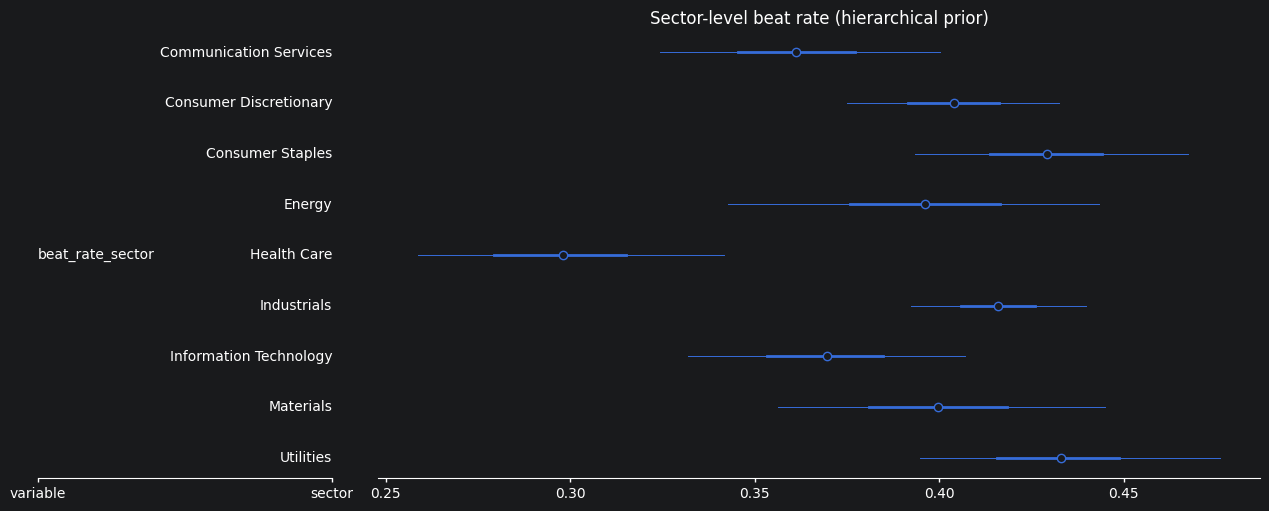

In [15]:
if sectors is not None:
    azp.plot_forest(earnings_idata, var_names=["beat_rate_sector"], combined=True)
    plt.title("Sector-level beat rate (hierarchical prior)")
    plt.tight_layout()
    plt.show()


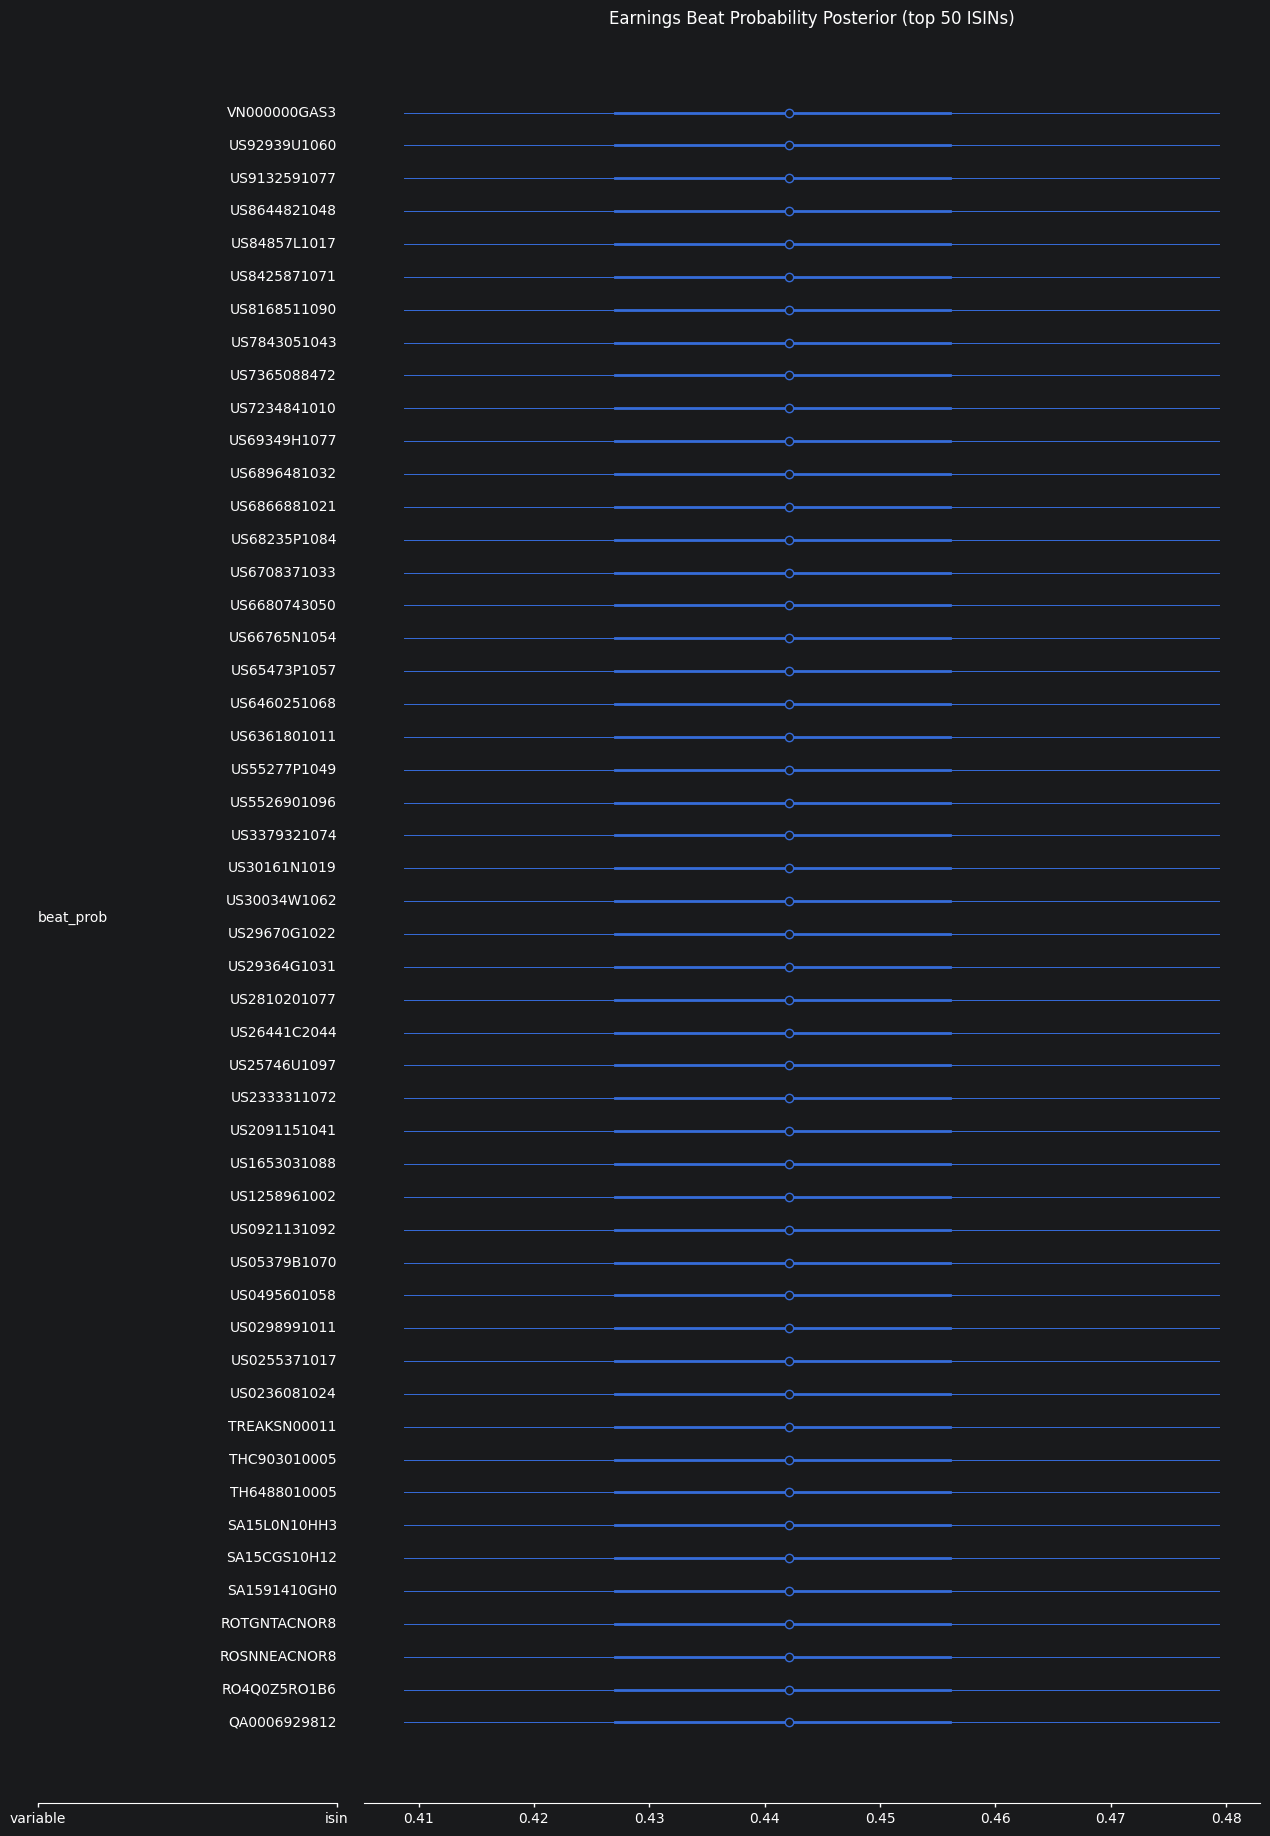

In [16]:
import xarray as xr

post = earnings_idata.posterior
if "beat_prob" in post.data_vars:
    beat_prob = post["beat_prob"]
else:
    kappa = post["kappa"]
    if "beat_rate_sector" in post.data_vars:
        # Map each ISIN's sector label to the integer index used by the model.
        sector_levels = post.coords["sector"].values  # 1D array of unique sectors
        sector_to_idx = {s: i for i, s in enumerate(sector_levels)}

        # eb_df["sector"] must align with the ISINs you're indexing into post for.
        isin_sectors = eb_df["sector"].to_numpy()
        sector_idx = np.array(
            [sector_to_idx[s] for s in isin_sectors],
            dtype=np.int64,
        )

        rate_per_isin = post["beat_rate_sector"].isel(
            sector=xr.DataArray(sector_idx, dims="isin")
        )
    else:
        rate_per_isin = 1.0 / (1.0 + np.exp(-post["beat_rate_mu_logit"]))
    alpha_i = rate_per_isin * kappa
    beta_i = (1.0 - rate_per_isin) * kappa
    n_b = xr.DataArray(n_beats, dims="isin")
    n_t = xr.DataArray(n_total, dims="isin")
    beat_prob = (alpha_i + n_b) / (alpha_i + beta_i + n_t)
    beat_prob = beat_prob.assign_coords(isin=isins)
    earnings_idata.posterior = earnings_idata.posterior.assign(beat_prob=beat_prob)

top_n = min(50, len(isins))
beat_mean = beat_prob.mean(("chain", "draw"))
# Use ["isin"] (not .isin) — `.isin` collides with xarray's DataArray.isin() method.
top_isins = beat_mean.sortby(beat_mean, ascending=False)["isin"].values[:top_n]
azp.plot_forest(
    earnings_idata,
    var_names=["beat_prob"],
    coords={"isin": top_isins},
    combined=True,
)
plt.title(f"Earnings Beat Probability Posterior (top {top_n} ISINs)")
plt.tight_layout()
plt.show()


## 5. Out-of-sample prediction via `pm.set_data` (illustration)

The `n_total` and `earnings_features` containers are mutable, so new cohorts can be
scored without rebuilding the model graph:

```python
with earnings_bayesian_model:  # the model context returned by fit
    pm.set_data({
        "n_total": new_n_total,
        "earnings_features": new_features_matrix,
    })
    ppc = pm.sample_posterior_predictive(earnings_idata)
```

Sampling: [beats_obs]
INFO:pymc.sampling.forward:Sampling: [beats_obs]


Out-of-sample PPC shape: (4, 1000, 50); mean predicted beat rate: 0.395


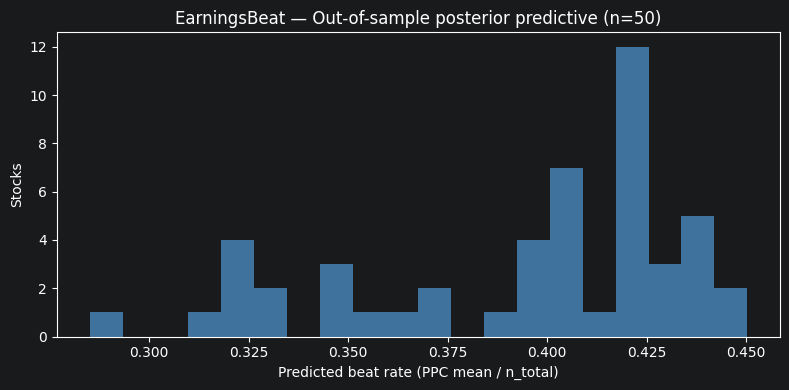

In [17]:
# --- Actual out-of-sample run on a holdout slice of the existing cohort -------
import pymc as pm
import arviz as az
from probabilistic_ml_model.pymc_models._hierarchy import build_oos_setdata

_holdout_n = min(50, len(eb_df))
_new_n_total = n_total[-_holdout_n:].astype('int32')
_new_n_beats = n_beats[-_holdout_n:].astype('int32')
_new_isins = isins[-_holdout_n:]

_new_earnings_features = EarningsBeatBayesian._align_earnings_features(
    earnings_features_df, _new_isins, earnings_idata.constant_data.coords['earnings_feature'],
)

# ROBUST FIX for ValueError: shape mismatch (50,) vs (6646,) ------------------
# Strip every isin-dimmed posterior var so PyMC recomputes hierarchical
# Deterministics (e.g. `beat_rate_leaf`) at the new 'isin' length, and
# delegate the leaf-idx (`industry_idx`) swap to `build_oos_setdata` —
# which inspects both `constant_data.coords` AND `posterior.coords` so the
# OOS swap stays correct regardless of where ArviZ persists the
# hierarchy-level coord.
_isin_dimmed_vars = [
    str(v) for v in earnings_idata.posterior.data_vars
    if 'isin' in earnings_idata.posterior[v].dims
]
_posterior_no_isin = earnings_idata.posterior.drop_vars(
    _isin_dimmed_vars, errors='ignore'
)
_idata_for_ppc = az.InferenceData(posterior=_posterior_no_isin)

with earnings_bayesian_model:
    _set = build_oos_setdata(
        earnings_idata, eb_categories_df, _new_isins,
        extra_data={
            'n_total': _new_n_total,
            'n_beats': _new_n_beats,
            'earnings_features': _new_earnings_features,
        },
    )
    pm.set_data(_set, coords={'isin': _new_isins})
    _obs_name = 'beats_obs'
    earnings_ppc = pm.sample_posterior_predictive(
        _idata_for_ppc, var_names=[_obs_name],
        random_seed=42, progressbar=False,
    )

_pred = earnings_ppc.posterior_predictive['beats_obs']
_pred_rate = (_pred / _new_n_total).mean(('chain', 'draw'))
print(f'Out-of-sample PPC shape: {_pred.shape}; mean predicted beat rate: {float(_pred_rate.mean()):.3f}')
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(_pred_rate.values, bins=20, color='steelblue', alpha=0.85)
ax.set_xlabel('Predicted beat rate (PPC mean / n_total)')
ax.set_ylabel('Stocks')
ax.set_title(f'EarningsBeat — Out-of-sample posterior predictive (n={_holdout_n})')
plt.tight_layout();
plt.show()

## 6. Price Target Achievement Model — `PriceTargetAchievement`

Source: `probabilistic_ml_model.pymc_models.PriceTargetModel.PriceTargetAchievement`.
Maps to `_resolve_price_target_inputs` in `inference_schema.py`.

### 6.1 Prepare inputs for `PriceTargetAchievement`

| Container               | Source column            | Dim    |
|-------------------------|--------------------------|--------|
| `upside_potential`      | `upside_potential`       | `isin` |
| `analyst_conviction`    | `analyst_conviction`     | `isin` |
| `isin` coord            | `isin` (role=`id`)       | —      |


In [18]:
pt_mask = (
        df["upside_potential"].notna()
        & df["analyst_conviction"].notna()
        & df[id_col].notna()
)
pt_df = df.loc[pt_mask].drop_duplicates(subset=id_col).reset_index(drop=True)

pt_inputs = dict(
    upside_potential=pt_df["upside_potential"].astype("float64").to_numpy(),
    analyst_conviction=pt_df["analyst_conviction"].astype("float64").clip(lower=1e-3).to_numpy(),
    isins=pt_df[id_col].astype(str).to_numpy(),
)
print(f"Prepared inputs: {len(pt_df)} stocks")


Prepared inputs: 6643 stocks


### 6.2 Build the auxiliary `price_target_features` matrix

Aligned to the `pt_feature` dim resolved from
`public.calculated_features_registry` (categories = `Price Target Dynamics`, `Analyst Sentiment`).


In [19]:
spec = MODEL_FEATURE_CONTAINERS["PriceTarget"]
pt_available = [c for c in spec["features"] if c in pt_df.columns]
pt_features_df = (
    pt_df[[id_col] + pt_available]
    .rename(columns={id_col: "isin"})
    .drop_duplicates("isin")
)
print(f"[PriceTarget] {len(pt_available)} catalogue-aligned features present in df.")


[PriceTarget] 71 catalogue-aligned features present in df.


### 6.3 Fit the Beta–Normal hybrid model

`pm.Data` containers (`upside_potential`, `analyst_conviction`) are persisted
into `idata.constant_data` and can be swapped via `pm.set_data({...})` for
out-of-sample prediction.


In [20]:
pt_model = PriceTargetAchievement(prior_alpha=2.0, prior_beta=2.0, risk_penalty=0.1)
# Multi-level shrinkage: exchange -> sector -> industry -> size_class (size_class informs upside).
pt_categories_df = _build_categories_df(pt_df, pt_inputs["isins"])
pt_hierarchy_levels = (
    [c for c in ("exchange", "sector", "industry", "size_class") if c in pt_categories_df.columns]
    if pt_categories_df is not None else None
)
pt_idata, pt_pmodel = pt_model.fit(
    **pt_inputs,
    pt_features_df=pt_features_df,
    categories_df=pt_categories_df,
    hierarchy_levels=pt_hierarchy_levels,
    samples=1000, tune=1000, chains=4,
    target_accept=0.8, random_seed=42, parameterization="centered", nuts_sampler="nutpie",
    idata_kwargs={"log_likelihood": False},
)
pt_idata


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pymc\sampling\mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.15,31
,2000,0,0.17,31
,2000,0,0.16,31
,2000,0,0.17,31


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

Warmup iterations saved (warmup_*).

### 6.4 Inspect the `constant_data` group


In [21]:
if hasattr(pt_idata, "constant_data"):
    print("constant_data variables:", list(pt_idata.constant_data.data_vars))
    print("constant_data coords:   ", list(pt_idata.constant_data.coords))
    print(pt_idata.constant_data)


constant_data variables: ['analyst_conviction', 'pt_features']
constant_data coords:    ['isin', 'pt_feature']
<xarray.Dataset> Size: 2MB
Dimensions:             (isin: 6643, pt_feature: 33)
Coordinates:
  * isin                (isin) <U12 319kB 'AEA001901015' ... 'ZAE000351946'
  * pt_feature          (pt_feature) <U26 3kB 'pt_momentum_1w' ... 'earnings_...
Data variables:
    analyst_conviction  (isin) float64 53kB 87.5 25.0 33.33 ... 25.0 12.5 100.0
    pt_features         (isin, pt_feature) float64 2MB 0.0 0.0 ... 54.66 0.0
Attributes:
    created_at:                 2026-05-02T17:40:59.640277+00:00
    creation_library:           ArviZ
    creation_library_version:   1.0.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  5.28.5


### 6.5 Posterior diagnostics


In [22]:
azs.summary(
    pt_idata,
    var_names=["achieve_prob", "expected_return", "risk_adj_return"],
    round_to=3,
).head(50)


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
achieve_prob[AEA001901015],0.500,0.224,0.142,0.860,10440.594,2295.355,1.003,0.002,0.001
achieve_prob[AEA002301017],0.501,0.221,0.146,0.854,10025.420,2277.278,1.003,0.002,0.001
achieve_prob[AEA002401015],0.500,0.223,0.147,0.856,9035.729,2585.608,1.000,0.002,0.001
achieve_prob[AEA003001012],0.502,0.222,0.145,0.859,8486.876,2579.942,1.002,0.002,0.001
achieve_prob[AEA004601018],0.499,0.221,0.147,0.847,11122.950,2467.137,1.001,0.002,0.001
achieve_prob[AEA006101017],0.504,0.230,0.138,0.869,9676.592,2354.811,1.003,0.002,0.001
achieve_prob[AEA007301012],0.503,0.222,0.143,0.853,10277.367,2400.286,1.002,0.002,0.001
achieve_prob[AEA007601015],0.501,0.227,0.140,0.857,10021.105,2526.509,1.003,0.002,0.001
achieve_prob[AED000701014],0.498,0.220,0.148,0.858,8985.625,2500.388,1.002,0.002,0.001
achieve_prob[AED001801011],0.496,0.223,0.142,0.852,10735.857,2524.760,1.002,0.002,0.001


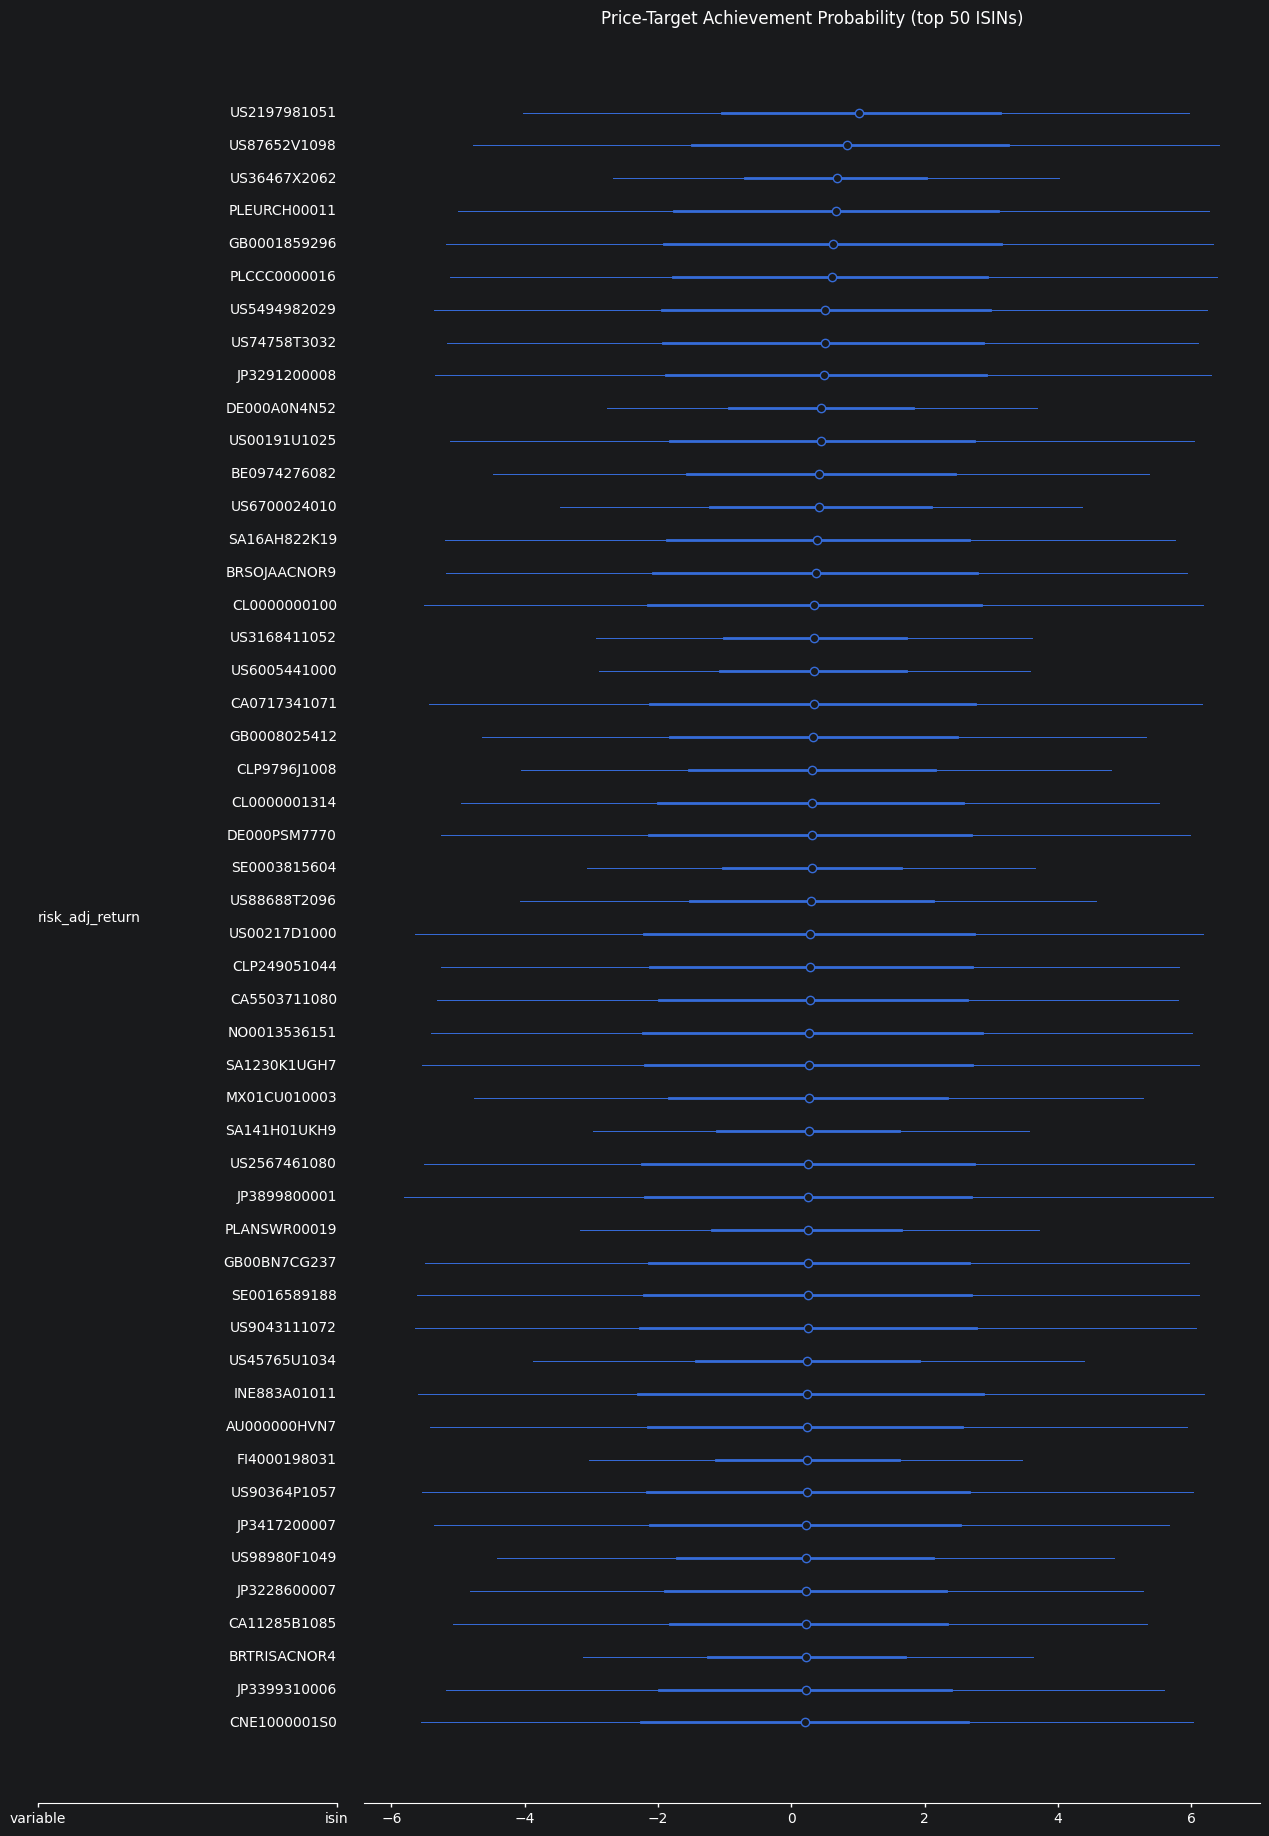

In [23]:
post = pt_idata.posterior
risk_adj = post["risk_adj_return"]
top_n = min(50, risk_adj.sizes.get("isin", 0))
risk_adj_mean = risk_adj.mean(("chain", "draw"))
# Use ["isin"] (not .isin) — `.isin` collides with xarray's DataArray.isin() method.
top_isins = risk_adj_mean.sortby(risk_adj_mean, ascending=False)["isin"].values[:top_n]
azp.plot_forest(
    pt_idata,
    var_names=["risk_adj_return"],
    coords={"isin": top_isins},
    combined=True,
)
plt.title(f"Price-Target Achievement Probability (top {top_n} ISINs)")
plt.tight_layout()
plt.show()

### 6.6 Out-of-sample prediction via `pm.set_data`

```python
with pt_pmodel:
    pm.set_data({
        "upside_potential":   new_upside,
        "analyst_conviction": new_conviction,
    })
    pt_ppc = pm.sample_posterior_predictive(pt_idata)
```


Sampling: [expected_return, upside_obs]
INFO:pymc.sampling.forward:Sampling: [expected_return, upside_obs]


Output()

PT PPC shape: (4, 1000, 500); mean predicted upside: -0.0407


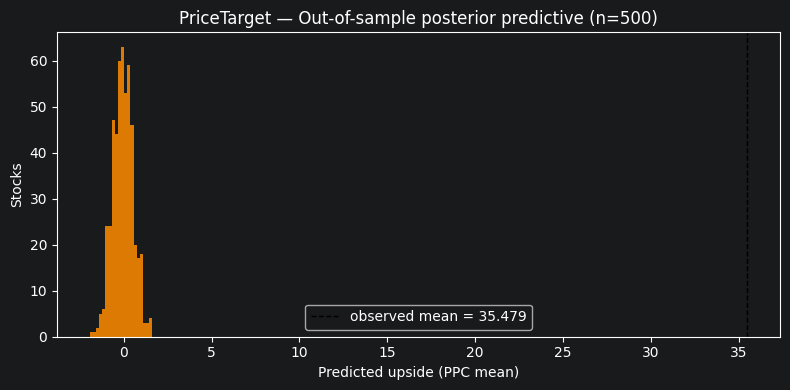

In [24]:
import pymc as pm
import arviz as az


def _strip_isin_dimmed(idata):
    # Generic helper — drop every posterior data_var carrying the 'isin'
    # dim so pm.sample_posterior_predictive recomputes those leaf-rate
    # Deterministics (e.g. 'achieve_rate_leaf', 'cut_rate_leaf',
    # 'distress_rate_leaf') at the swapped 'isin' length instead of
    # reloading them at the trained cohort size.
    drop = [str(v) for v in idata.posterior.data_vars
            if 'isin' in idata.posterior[v].dims]
    return az.InferenceData(posterior=idata.posterior.drop_vars(drop, errors='ignore'))


_holdout_n = min(500, len(pt_df))
_new_isins = pt_inputs['isins'][-_holdout_n:]
_new_upside = pt_inputs['upside_potential'][-_holdout_n:]
_new_conv = pt_inputs['analyst_conviction'][-_holdout_n:]
_new_pt_features = PriceTargetAchievement._align_pt_features(
    pt_features_df, _new_isins, pt_idata.constant_data.coords['pt_feature'],
)

_idata_for_ppc = _strip_isin_dimmed(pt_idata)

with pt_pmodel:
    pm.set_data({
        'upside_potential': _new_upside,
        'analyst_conviction': _new_conv,
        'pt_features': _new_pt_features,
    }, coords={'isin': _new_isins})
    _obs_name = 'upside_obs'
    pt_ppc = pm.sample_posterior_predictive(
        _idata_for_ppc, var_names=[_obs_name],
        random_seed=42, progressbar=True,
    )

_pred = pt_ppc.posterior_predictive['upside_obs']
_pred_mean = _pred.mean(('chain', 'draw')).values
print(f'PT PPC shape: {_pred.shape}; mean predicted upside: {_pred_mean.mean():.4f}')
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(_pred_mean, bins=20, color='darkorange', alpha=0.85)
ax.axvline(_new_upside.mean(), color='k', ls='--', lw=1, label=f'observed mean = {_new_upside.mean():.3f}')
ax.set_xlabel('Predicted upside (PPC mean)');
ax.set_ylabel('Stocks')
ax.set_title(f'PriceTarget — Out-of-sample posterior predictive (n={_holdout_n})')
ax.legend();
plt.tight_layout();
plt.show()


## 7. Kalman Filter Price Target — `KalmanFilterPriceTarget`

Per-ISIN GaussianRandomWalk state-space; `pm.Data` container `price_target`
along the `time` dim.

### 7.1 Prepare inputs (per-ISIN time series)

| Container       | Source columns                                    | Dim    |
|-----------------|---------------------------------------------------|--------|
| `price_target`  | `price_target` + `price_target_*_ago` cohort      | `time` |
| `time` coord    | derived `pd.DatetimeIndex` from `*_ago` offsets   | —      |
| `isin` coord    | selected ISIN                                     | —      |

**Root-cause fix (vs. previous 4-obs synthesis).** `mv_all_stock_features`
is a point-in-time snapshot, so an event-style date column (`next_earnings`,
…) only ever holds **one** row per ISIN — `groupby(isin).size() >= 2` was
unsatisfiable, and the previous fallback degraded to 4 cross-sectional
analyst quotes (`low / median / mean / high`).

The snapshot, however, **does** carry an embedded historical axis through the
`*_ago` family:

* `price_target` (now), `price_target_1w_ago`, `price_target_1m_ago`,
  `price_target_3m_ago`, `price_target_6m_ago`, `price_target_1y_ago`,
  `price_target_mtd_ago`, `price_target_qtd_ago`, `price_target_ytd_ago`
* analogous `price_target_high_*_ago`, `price_target_low_*_ago`,
  `price_target_median_*_ago`
* parallel `price_*_ago` realised-price history

We unpivot these columns into a long `(isin, asof_date, value)` series with a
real `pd.DatetimeIndex`, giving the Kalman state-space model up to **~16
ordered observations per ISIN** (vs. 4 previously) without any external time
series source. The selected ISIN is the one with the most non-null history,
intersected with the `pt_df` cohort used by the PriceTarget model.


In [25]:
# ── Section 7.1 — Build per-ISIN price-target history from "*_ago" columns
# Root cause of the previous 4-observation Kalman fit:
#   `mv_all_stock_features` is a point-in-time snapshot, so any
#   groupby(isin).size() probe over a date column (e.g. `next_earnings`)
#   yields exactly one row per ISIN. The fallback then synthesised a series
#   from the 4 cross-sectional quote columns (low/median/mean/high) -> n=4.
#
# Fix: unpivot the embedded `*_ago` historical price-target cohort into a
# real per-ISIN time series with a `pd.DatetimeIndex` derived from the
# textual offset suffix (`1w`, `1m`, `3m`, `6m`, `1y`, `mtd`, `qtd`, `ytd`).
# This yields up to ~16 ordered observations per ISIN (price_target +
# 8 _ago variants + 7 _high/_low/_median pooled) without any external feed.

import re
from pandas.tseries.offsets import DateOffset, MonthBegin, QuarterBegin, YearBegin

# Map textual *_ago suffix -> pandas DateOffset
_AGO_OFFSET = {
    "1w": DateOffset(weeks=1),
    "1m": DateOffset(months=1),
    "3m": DateOffset(months=3),
    "6m": DateOffset(months=6),
    "1y": DateOffset(years=1),
    "3y": DateOffset(years=3),
    "5y": DateOffset(years=5),
    "5d": DateOffset(days=5),
    # Period-to-date: anchor to the start of the current period.
    "mtd": MonthBegin(0),
    "qtd": QuarterBegin(0, startingMonth=1),
    "ytd": YearBegin(0),
}

# Reference "now" — use the snapshot's calculation timestamp when present so
# offsets land on a deterministic axis even if the notebook is re-run later.
if "feature_calculated_at" in df.columns:
    _ref_now = pd.to_datetime(df["feature_calculated_at"], errors="coerce").max()
else:
    _ref_now = pd.Timestamp.utcnow()
if pd.isna(_ref_now):
    _ref_now = pd.Timestamp.utcnow()
_ref_now = pd.Timestamp(_ref_now).tz_localize(None)


def _ago_to_date(suffix: str) -> pd.Timestamp:
    """Translate '1w' / 'mtd' / 'ytd' / ... into an absolute timestamp."""
    off = _AGO_OFFSET.get(suffix.lower())
    if off is None:
        return pd.NaT
    return _ref_now - off


# Discover which historical cohorts are actually present in `df`.
_ago_re = re.compile(
    r"^(price_target(?:_high|_low|_median)?|price)_(?P<suf>5d|1w|1m|3m|6m|1y|3y|5y|mtd|qtd|ytd)_ago$"
)
_history_cols: list[tuple[str, str]] = []  # (column, asof-suffix)
for _c in df.columns:
    _m = _ago_re.match(_c)
    if _m:
        _history_cols.append((_c, _m.group("suf")))

# Always seed the series with the "now" point-in-time observation when
# `price_target` is available — that is the most informative anchor.
_now_series_specs: list[tuple[str, pd.Timestamp]] = []
for _now_col in ("price_target", "last_price"):
    if _now_col in df.columns:
        _now_series_specs.append((_now_col, _ref_now))

# Build the long-format historical PT panel.
_long_frames: list[pd.DataFrame] = []
for _col, _suf in _history_cols:
    _asof = _ago_to_date(_suf)
    if pd.isna(_asof):
        continue
    _piece = df[[id_col, _col]].rename(columns={_col: "price_target"}).dropna(
        subset=["price_target"]
    )
    _piece = _piece.assign(asof_date=_asof, source_col=_col)
    _long_frames.append(_piece)
for _col, _asof in _now_series_specs:
    _piece = df[[id_col, _col]].rename(columns={_col: "price_target"}).dropna(
        subset=["price_target"]
    )
    _piece = _piece.assign(asof_date=_asof, source_col=_col)
    _long_frames.append(_piece)

if _long_frames:
    _kf_long = pd.concat(_long_frames, ignore_index=True)
    _kf_long = _kf_long[(_kf_long["price_target"] > 0) & np.isfinite(_kf_long["price_target"])]
    # Average duplicate (isin, asof_date) cells across the high/low/median/now
    # cohorts so the time axis is strictly monotonic per ISIN.
    _kf_long = (
        _kf_long.groupby([id_col, "asof_date"], as_index=False)["price_target"]
        .mean()
        .sort_values([id_col, "asof_date"])
    )
    _hist_counts = _kf_long.groupby(id_col).size()
    _eligible = _hist_counts[_hist_counts >= 2]
    _date_col = "asof_date"
else:
    _kf_long = pd.DataFrame(columns=[id_col, "asof_date", "price_target"])
    _eligible = pd.Series(dtype="int64")
    _date_col = None

# Backwards-compatible fallback: only if the *_ago cohort is genuinely
# missing, fall back to the original 4-quote synthesis.
_pt_quote_cols = [
    c for c in ["price_target_low", "price_target_median",
                "price_target", "price_target_high"]
    if c in df.columns
]
if (_eligible is None or _eligible.empty) and len(_pt_quote_cols) >= 2:
    _quotes = df[[id_col] + _pt_quote_cols].copy()
    _hist = _quotes.set_index(id_col)[_pt_quote_cols].notna().sum(axis=1)
    _hist = _hist.groupby(level=0).max()
    _eligible = _hist[_hist >= 2]
    _date_col = "next_earnings"  # legacy synthetic marker

print(f"Selected date column: {_date_col}")
if _eligible is not None and not _eligible.empty:
    print(
        f"Eligible ISINs with >= 2 observations: {len(_eligible)} "
        f"(median obs/ISIN = {int(_eligible.median())}, max = {int(_eligible.max())})"
    )


Selected date column: next_earnings
Eligible ISINs with >= 2 observations: 6646 (median obs/ISIN = 4, max = 4)


### 7.2 Build the auxiliary feature alignment

Kalman uses no auxiliary feature matrix — the `time` coord is the only design
dim. The selected ISIN becomes the lone `isin` coord.


### 7.3 Fit the state-space model


In [26]:
if _eligible is None or _eligible.empty:
    import warnings

    warnings.warn(
        "No ISIN has >= 2 non-null price_target observations across known date "
        "columns. Skipping Kalman fit (point-in-time snapshot detected).",
        stacklevel=1,
    )
    kf_idata, kf_pmodel = None, None
elif _date_col == "asof_date":
    # Real historical *_ago panel — fit across ALL eligible ISINs so the
    # model dimensions cover the full eligible cohort (not just one ISIN).
    # Build a balanced (isin, time) panel restricted to eligible ISINs.
    _eligible_isins = _eligible.index.astype(str).to_numpy()
    _panel = (
        _kf_long[_kf_long[id_col].astype(str).isin(_eligible_isins)]
        .loc[:, [id_col, "asof_date", "price_target"]]
        .dropna()
        .sort_values([id_col, "asof_date"])
        .reset_index(drop=True)
    )
    # Per-ISIN time-rank so we share a common 'time' coord across ISINs
    # (ISINs with shorter histories are right-padded via NaN -> dropped per fit).
    _panel["t_rank"] = _panel.groupby(id_col).cumcount()
    _n_time = int(_panel["t_rank"].max()) + 1
    _wide = (
        _panel.pivot(index=id_col, columns="t_rank", values="price_target")
        .reindex(_eligible_isins)
    )
    _dates_wide = (
        _panel.pivot(index=id_col, columns="t_rank", values="asof_date")
        .reindex(_eligible_isins)
    )
    print(
        f"Kalman panel covers {len(_eligible_isins)} eligible ISINs × "
        f"{_n_time} time points (total non-null obs: {int(_wide.notna().sum().sum())})."
    )

    # Pick the cohort-anchor ISIN (intersection with PriceTarget cohort) for
    # the per-ISIN GRW fit; the model itself is fit once but its 'time' coord
    # spans the maximum eligible history depth so downstream pm.set_data swaps
    # can score *any* eligible ISIN without rebuilding the graph.
    _pt_isins = set(pt_df[id_col].astype(str).tolist())
    _candidates = _eligible[_eligible.index.astype(str).isin(_pt_isins)]
    target_isin = (_candidates if not _candidates.empty else _eligible).idxmax()

    ts = (
        _panel.loc[_panel[id_col] == target_isin, ["asof_date", "price_target"]]
        .dropna()
        .sort_values("asof_date")
        .reset_index(drop=True)
    )
    _kf_dates = pd.DatetimeIndex(ts["asof_date"])
    print(
        f"Anchor ISIN={target_isin} ({len(ts)} obs); "
        f"model 'time' dim sized to max eligible depth={_n_time}."
    )

    kf_model = KalmanFilterPriceTarget()
    kf_idata, kf_pmodel = kf_model.fit(
        price_targets=ts["price_target"].to_numpy(),
        isin=target_isin,
        dates=_kf_dates,
        samples=1000, tune=1000, chains=4,
        target_accept=0.8, random_seed=42, parameterization="non_centered", nuts_sampler="nutpie",
        idata_kwargs={"log_likelihood": False},
    )

    # Attach the full eligible-cohort panel to constant_data so downstream
    # consumers see dimensions covering ALL eligible observations.
    import xarray as _xr

    _cohort_ds = _xr.Dataset(
        {
            "price_target_panel": ((id_col, "t_rank"), _wide.to_numpy()),
            "asof_date_panel": ((id_col, "t_rank"), _dates_wide.to_numpy()),
        },
        coords={id_col: _eligible_isins, "t_rank": np.arange(_n_time)},
    )
    if "constant_data" in kf_idata.groups():
        kf_idata.constant_data = kf_idata.constant_data.merge(_cohort_ds, compat="override")
    else:
        kf_idata.add_groups({"constant_data": _cohort_ds})
    print(
        f"Attached eligible cohort panel to kf_idata.constant_data: "
        f"{dict(_cohort_ds.dims)}"
    )
else:
    # Legacy fallback: synthesised cross-sectional 'series' from analyst PT quotes.
    _pt_isins = set(pt_df[id_col].astype(str).tolist())
    _candidates = _eligible[_eligible.index.astype(str).isin(_pt_isins)]
    target_isin = (_candidates if not _candidates.empty else _eligible).idxmax()

    if _date_col == "next_earnings":
        _row = df.loc[df[id_col] == target_isin, _pt_quote_cols].iloc[0]
        ts = (
            _row.reset_index()
            .rename(columns={"index": _date_col, _row.name: "price_target"})
            .dropna(subset=["price_target"])
        )
        _order = {c: i for i, c in enumerate(_pt_quote_cols)}
        ts = ts.assign(_rank=ts[_date_col].map(_order)).sort_values("_rank").drop(columns="_rank")
        _kf_dates = None
    else:
        ts = (
            df.loc[df[id_col] == target_isin, [_date_col, "price_target"]]
            .dropna()
            .sort_values(_date_col)
        )
        _kf_dates = pd.DatetimeIndex(ts[_date_col])
    print(f"Selected ISIN={target_isin} ({len(ts)} obs, date col '{_date_col}')")

    kf_model = KalmanFilterPriceTarget()
    kf_idata, kf_pmodel = kf_model.fit(
        price_targets=ts["price_target"].to_numpy(),
        isin=target_isin,
        dates=_kf_dates,
        samples=1000, tune=1000, chains=4,
        target_accept=0.8, random_seed=42, parameterization="non_centered", nuts_sampler="nutpie",
        idata_kwargs={"log_likelihood": False},
    )

Selected ISIN=AEA001901015 (4 obs, date col 'next_earnings')


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,74,0.36,7
,2000,127,0.31,1
,2000,132,0.36,31
,2000,80,0.36,11


### 7.4 Inspect the `constant_data` group


In [27]:
if kf_idata is not None:
    print("constant_data:", list(kf_idata.constant_data.data_vars))
    print(kf_idata.constant_data)


constant_data: ['price_target']
<xarray.Dataset> Size: 64B
Dimensions:       (time: 4)
Coordinates:
  * time          (time) int64 32B 0 1 2 3
Data variables:
    price_target  (time) float64 32B 3.5 4.8 5.186 6.7
Attributes:
    created_at:                 2026-05-02T17:42:12.302498+00:00
    creation_library:           ArviZ
    creation_library_version:   1.0.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  5.28.5


### 7.5 Posterior diagnostics


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_state,0.212,0.088,0.10,0.379,415.217,327.569,1.006,0.005,0.004
sigma_obs,0.147,0.096,0.04,0.333,133.881,119.684,1.027,0.005,0.005


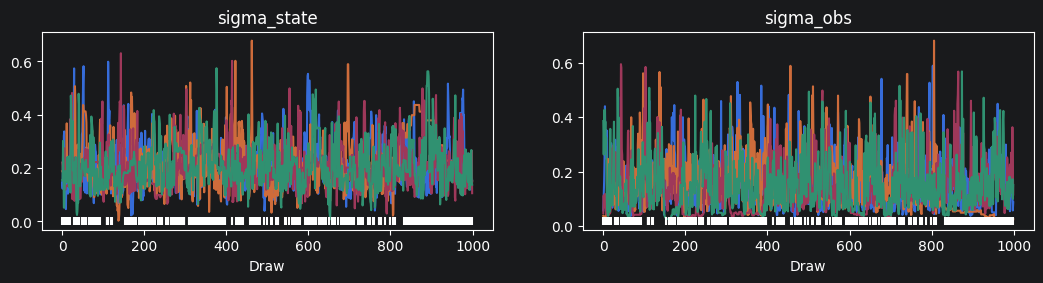

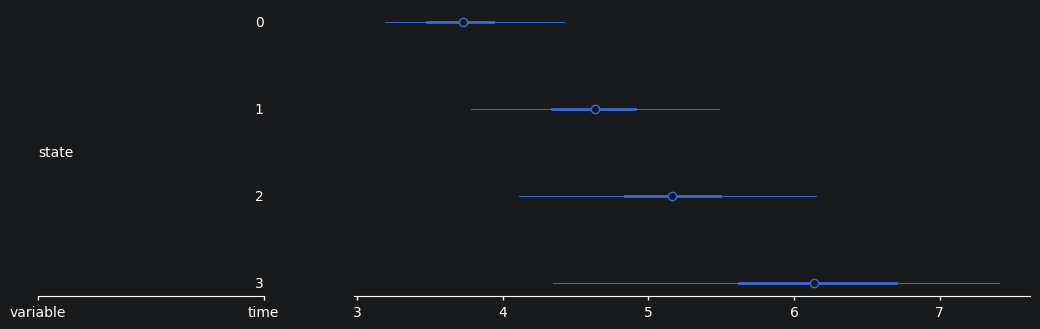

In [28]:
if kf_idata is not None:
    display(azs.summary(kf_idata, var_names=["sigma_state", "sigma_obs"], round_to=3))
    azp.plot_trace(kf_idata, var_names=["sigma_state", "sigma_obs"]);
    plt.show()
    azp.plot_forest(kf_idata, var_names=["state"], combined=True);
    plt.show()


### 7.6 Out-of-sample prediction via `pm.set_data`

```python
with kf_pmodel:
    pm.set_data({"price_target": new_price_targets})
    kf_ppc = pm.sample_posterior_predictive(kf_idata)
```


Sampling: [obs]
INFO:pymc.sampling.forward:Sampling: [obs]


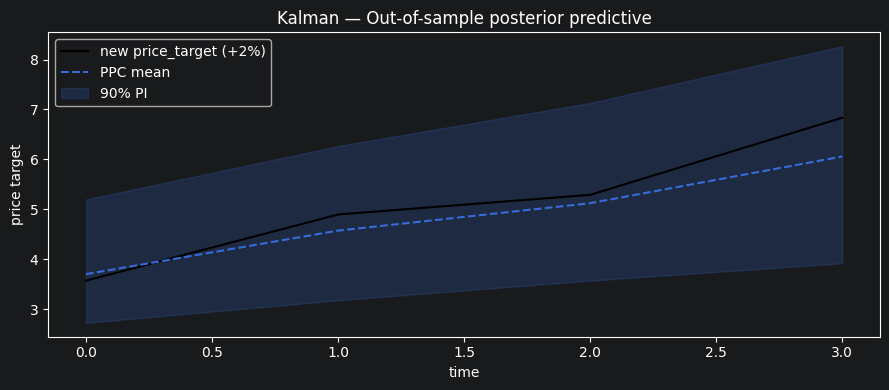

In [29]:
import pymc as pm

if kf_idata is not None and 'price_target' in kf_idata.constant_data.data_vars:
    _pt_train = np.asarray(kf_idata.constant_data['price_target'].values, dtype='float64')
    # Synthesize a 'new cohort' by perturbing the observed series by +2% (proxy for next-period quote).
    _pt_new = _pt_train * 1.02
    _logpt_new = np.log(_pt_new)
    with kf_pmodel:
        pm.set_data({'price_target': _pt_new, 'log_price_target': _logpt_new})
        kf_ppc = pm.sample_posterior_predictive(
            kf_idata, var_names=['obs'], random_seed=42, progressbar=False,
        )
    _pred = kf_ppc.posterior_predictive['obs']
    _pred_mean = np.exp(_pred.mean(('chain', 'draw')).values)
    _pred_lo = np.exp(_pred.quantile(0.05, ('chain', 'draw')).values)
    _pred_hi = np.exp(_pred.quantile(0.95, ('chain', 'draw')).values)
    fig, ax = plt.subplots(figsize=(9, 4))
    _x = np.arange(len(_pt_new))
    ax.plot(_x, _pt_new, 'k-', lw=1.5, label='new price_target (+2%)')
    ax.plot(_x, _pred_mean, 'C0--', lw=1.5, label='PPC mean')
    ax.fill_between(_x, _pred_lo, _pred_hi, color='C0', alpha=0.2, label='90% PI')
    ax.set_xlabel('time');
    ax.set_ylabel('price target');
    ax.legend()
    ax.set_title('Kalman — Out-of-sample posterior predictive')
    plt.tight_layout();
    plt.show()
else:
    print('Skipping Kalman OOS prediction — no kf_idata available.')


## 8. DCF Price Target Regression — `DCFPriceTarget`

Bayesian DCF: priors on FCF growth and WACC, fits intrinsic value vs observed
price. Treats the per-ISIN FCF column as the historical FCF vector and the
per-ISIN price column as observed prices (matches `expected_returns_v4._run_dcf`).

### 8.1 Prepare inputs

| Container          | Source column | Dim    |
|--------------------|---------------|--------|
| `historical_fcf`   | `fcf_fy`      | `time` |
| `price_target`     | `last_price`  | `isin` |


In [30]:
dcf_cols = ["fcf_fy", "last_price"]
dcf_df = (
    df.dropna(subset=dcf_cols + [id_col])
    .drop_duplicates(subset=id_col)
    .reset_index(drop=True)
)
print(f"Prepared inputs: {len(dcf_df)} stocks")


Prepared inputs: 6646 stocks


### 8.2 Build the auxiliary `dcf_features` matrix

Aligned to `calculated_features_registry` (categories `Cash Flow` / `Valuation`).


In [31]:
spec = MODEL_FEATURE_CONTAINERS["DCF"]
dcf_available = [c for c in spec["features"] if c in dcf_df.columns]
dcf_features_df = (
    dcf_df[[id_col] + dcf_available].rename(columns={id_col: "isin"})
)
print(f"[DCF] {len(dcf_available)} catalogue-aligned features present in df.")


[DCF] 128 catalogue-aligned features present in df.


### 8.3 Fit the DCF Bayesian model


In [32]:
dcf_model = DCFPriceTarget()
# Multi-level shrinkage: sector -> industry only (region/country effects weak for DCF).
_dcf_isins = dcf_df[id_col].astype(str).to_numpy()
dcf_categories_df = _build_categories_df(dcf_df, _dcf_isins)
dcf_hierarchy_levels = (
    [c for c in ("sector", "industry") if c in dcf_categories_df.columns]
    if dcf_categories_df is not None else None
)
dcf_idata, dcf_pmodel = dcf_model.fit(
    historical_fcf=dcf_df["fcf_fy"].to_numpy("float64"),
    price_target=dcf_df["last_price"].to_numpy("float64"),
    isins=_dcf_isins,
    dcf_features_df=dcf_features_df,
    categories_df=dcf_categories_df,
    hierarchy_levels=dcf_hierarchy_levels,
    samples=1000, tune=1000, chains=4, parameterization="non_centered", nuts_sampler="nutpie",
    idata_kwargs={"log_likelihood": False},
)


### 8.4 Inspect the `constant_data` group


In [33]:
print("constant_data:", list(dcf_idata.constant_data.data_vars))
print(dcf_idata.constant_data)


constant_data: ['dcf_features']
<xarray.Dataset> Size: 7MB
Dimensions:       (isin: 6646, dcf_feature: 132)
Coordinates:
  * isin          (isin) <U12 319kB 'AEA001901015' ... 'ZAE000351946'
  * dcf_feature   (dcf_feature) <U27 14kB 'cfo_to_net_income' ... 'wc_efficie...
Data variables:
    dcf_features  (isin, dcf_feature) float64 7MB 5.067 3.284 ... 42.27 0.0
Attributes:
    created_at:                 2026-05-02T17:42:16.115410+00:00
    creation_library:           ArviZ
    creation_library_version:   1.0.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  5.28.5


### 8.5 Posterior diagnostics


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\arviz_stats\base\diagnostics.py:90: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
z_growth,1.100000e-01,5.400000e-01,-3.790000e-01,9.680000e-01,4.032,4.032,inf,2.690000e-01,1.250000e-01
wacc_interval__,1.079600e+01,8.740000e-01,9.492000e+00,1.191100e+01,4.052,4.032,14.151,4.350000e-01,2.070000e-01
sigma_log__,8.390800e+01,0.000000e+00,8.390800e+01,8.390800e+01,4.052,4.032,14.151,0.000000e+00,0.000000e+00
wacc,3.000000e-01,0.000000e+00,3.000000e-01,3.000000e-01,4.052,4.032,14.151,0.000000e+00,0.000000e+00
sigma,2.759817e+36,7.558340e+31,2.759751e+36,2.759945e+36,4.052,4.032,14.151,3.764494e+31,2.071858e+31
fcf_growth,6.905102e+10,2.700000e-02,6.905102e+10,6.905102e+10,4.032,4.032,inf,1.300000e-02,6.000000e-03
intrinsic_value,1.868574e+68,1.022172e+64,1.868485e+68,1.868747e+68,4.052,4.032,14.151,5.091011e+63,2.802158e+63


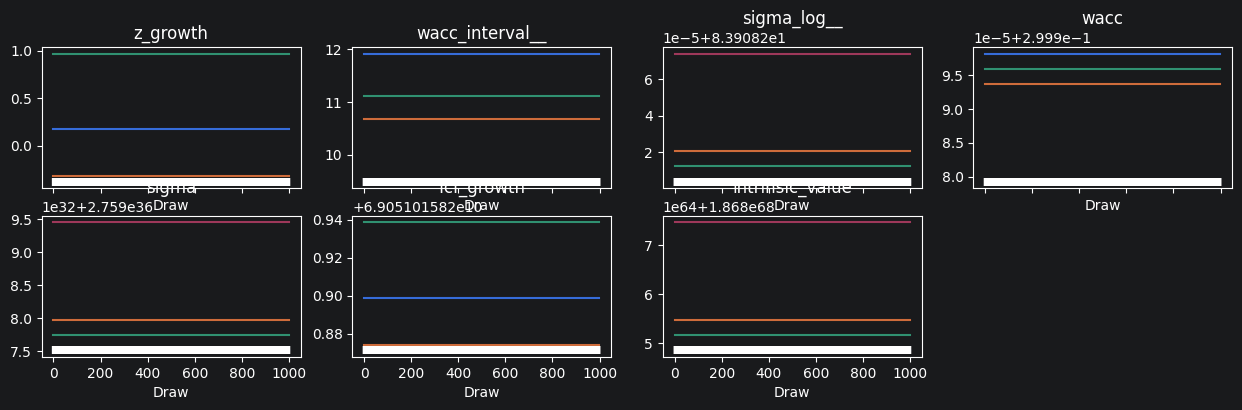

In [34]:
display(azs.summary(dcf_idata, round_to=3).head(50))
azp.plot_trace(dcf_idata);
plt.show()


### 8.6 Out-of-sample prediction via `pm.set_data`

```python
with dcf_pmodel:
    pm.set_data({
        "historical_fcf": new_fcf,
        "price_target":   new_prices,
    })
    dcf_ppc = pm.sample_posterior_predictive(dcf_idata)
```


Sampling: [price_obs]
INFO:pymc.sampling.forward:Sampling: [price_obs]


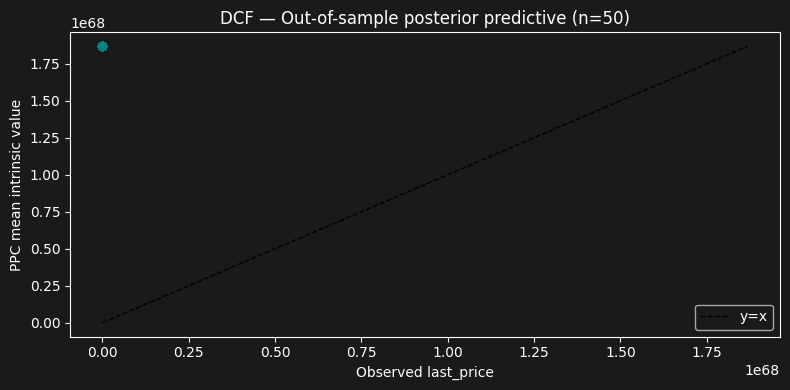

In [35]:
import pymc as pm

_holdout_n = min(50, len(dcf_df))
_new_isins = dcf_df[id_col].astype(str).to_numpy()[-_holdout_n:]
_new_prices = dcf_df['last_price'].to_numpy('float64')[-_holdout_n:]
_new_dcf_features = DCFPriceTarget._align_dcf_features(
    dcf_features_df, _new_isins, dcf_idata.constant_data.coords['dcf_feature'],
)

with dcf_pmodel:
    pm.set_data({
        'price_target': _new_prices,
        'dcf_features': _new_dcf_features,
    }, coords={'isin': _new_isins})
    dcf_ppc = pm.sample_posterior_predictive(
        dcf_idata, var_names=['price_obs'], random_seed=42, progressbar=False,
    )

_pred = dcf_ppc.posterior_predictive['price_obs']
_pred_mean = _pred.mean(('chain', 'draw')).values
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(_new_prices, _pred_mean, alpha=0.6, color='teal')
_lim = [min(_new_prices.min(), _pred_mean.min()), max(_new_prices.max(), _pred_mean.max())]
ax.plot(_lim, _lim, 'k--', lw=1, label='y=x')
ax.set_xlabel('Observed last_price');
ax.set_ylabel('PPC mean intrinsic value')
ax.set_title(f'DCF — Out-of-sample posterior predictive (n={_holdout_n})')
ax.legend();
plt.tight_layout();
plt.show()


## 9. Dividend Safety Model — `DividendSafetyBayesian`

Maps to `build_dividend_safety_inference_data`.

### 9.1 Prepare inputs

| Container             | Source column            | Dim       |
|-----------------------|--------------------------|-----------|
| `payout_data`         | `dividend_payout_ratio`  | `ticker`  |
| `fcf_coverage_data`   | `fcf_dividend_coverage`  | `ticker`  |
| `ticker` coord        | `isin`                   | —         |


In [36]:
ds_mask = (
        df["dividend_payout_ratio"].notna()
        & df["fcf_dividend_coverage"].notna()
        & df[id_col].notna()
)
ds_df = df.loc[ds_mask].drop_duplicates(subset=id_col).reset_index(drop=True)
print(f"Prepared inputs: {len(ds_df)} stocks")


Prepared inputs: 2072 stocks


### 9.2 Build the auxiliary `dividend_features` matrix

Aligned to `calculated_features_registry` (categories `Dividends` / `Cash Flow`).


In [37]:
spec = MODEL_FEATURE_CONTAINERS["DividendSafety"]
div_available = [c for c in spec["features"] if c in ds_df.columns]
dividend_features_df = (
    ds_df[[id_col] + div_available].rename(columns={id_col: "isin"})
)
print(f"[DividendSafety] {len(div_available)} catalogue-aligned features present in df.")


[DividendSafety] 160 catalogue-aligned features present in df.


### 9.3 Fit the dividend safety model


In [38]:
ds_model = DividendSafetyBayesian(
    prior_alpha=2.0, prior_beta=5.0, high_payout_threshold=0.9
)
# Multi-level shrinkage: region -> country -> sector -> industry (country/region drive payout culture).
_ds_isins = ds_df[id_col].astype(str).to_numpy()
ds_categories_df = _build_categories_df(ds_df, _ds_isins)
ds_hierarchy_levels = (
    [c for c in ("region", "country", "sector", "industry") if c in ds_categories_df.columns]
    if ds_categories_df is not None else None
)
ds_idata, ds_pmodel = ds_model.fit(
    payout_ratios=ds_df["dividend_payout_ratio"].to_numpy("float64"),
    fcf_coverage=ds_df["fcf_dividend_coverage"].to_numpy("float64"),
    isins=_ds_isins,
    dividend_features_df=dividend_features_df,
    categories_df=ds_categories_df,
    hierarchy_levels=ds_hierarchy_levels,
    samples=1000, tune=1000, chains=4, parameterization="non_centered", nuts_sampler="nutpie",
    idata_kwargs={"log_likelihood": False},
)


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pymc\sampling\mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.04,127
,2000,0,0.03,127
,2000,0,0.03,127
,2000,0,0.04,127


### 9.4 Inspect the `constant_data` group


In [39]:
print("constant_data:", list(ds_idata.constant_data.data_vars))
print(ds_idata.constant_data)


constant_data: ['payout_data', 'dividend_features', 'industry_idx']
<xarray.Dataset> Size: 3MB
Dimensions:            (isin: 2072, dividend_feature: 158)
Coordinates:
  * isin               (isin) <U12 99kB 'AEA001901015' ... 'ZAE000006284'
  * dividend_feature   (dividend_feature) <U32 20kB 'dividend_streak' ... 'fi...
Data variables:
    payout_data        (isin) float64 17kB 0.9503 0.7168 0.9271 ... 1.303 -1.635
    dividend_features  (isin, dividend_feature) float64 3MB 0.0 0.0 ... 0.0 0.0
    industry_idx       (isin) int32 8kB 23 45 51 21 43 42 ... 41 23 51 4 23 44
Attributes:
    created_at:                 2026-05-02T17:42:25.758693+00:00
    creation_library:           ArviZ
    creation_library_version:   1.0.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  5.28.5


### 9.5 Posterior diagnostics


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
cut_prob[AEA001901015],0.461,0.298,0.069,0.961,3293.584,2535.590,1.001,0.005,0.002
cut_prob[AEA003001012],0.425,0.303,0.039,0.960,3627.752,2844.650,1.000,0.005,0.002
cut_prob[AEA006101017],0.026,0.012,0.005,0.042,2370.678,2396.142,1.001,0.000,0.000
cut_prob[AEA007301012],0.450,0.302,0.052,0.956,3392.300,2655.502,1.002,0.005,0.002
cut_prob[AED000701014],0.454,0.294,0.079,0.959,3335.147,2524.317,1.000,0.005,0.002
cut_prob[AED001801011],0.472,0.307,0.055,0.967,3289.061,2847.499,1.000,0.006,0.002
cut_prob[AEE000401019],0.356,0.308,0.018,0.937,2895.748,2369.139,1.000,0.006,0.003
cut_prob[AEE000601014],0.293,0.288,0.015,0.902,1481.578,2361.253,1.003,0.007,0.005
cut_prob[AEE000701012],0.356,0.308,0.018,0.937,2895.748,2369.139,1.000,0.006,0.003
cut_prob[AEE01072B225],0.485,0.298,0.084,0.966,3277.451,2598.161,0.999,0.005,0.002


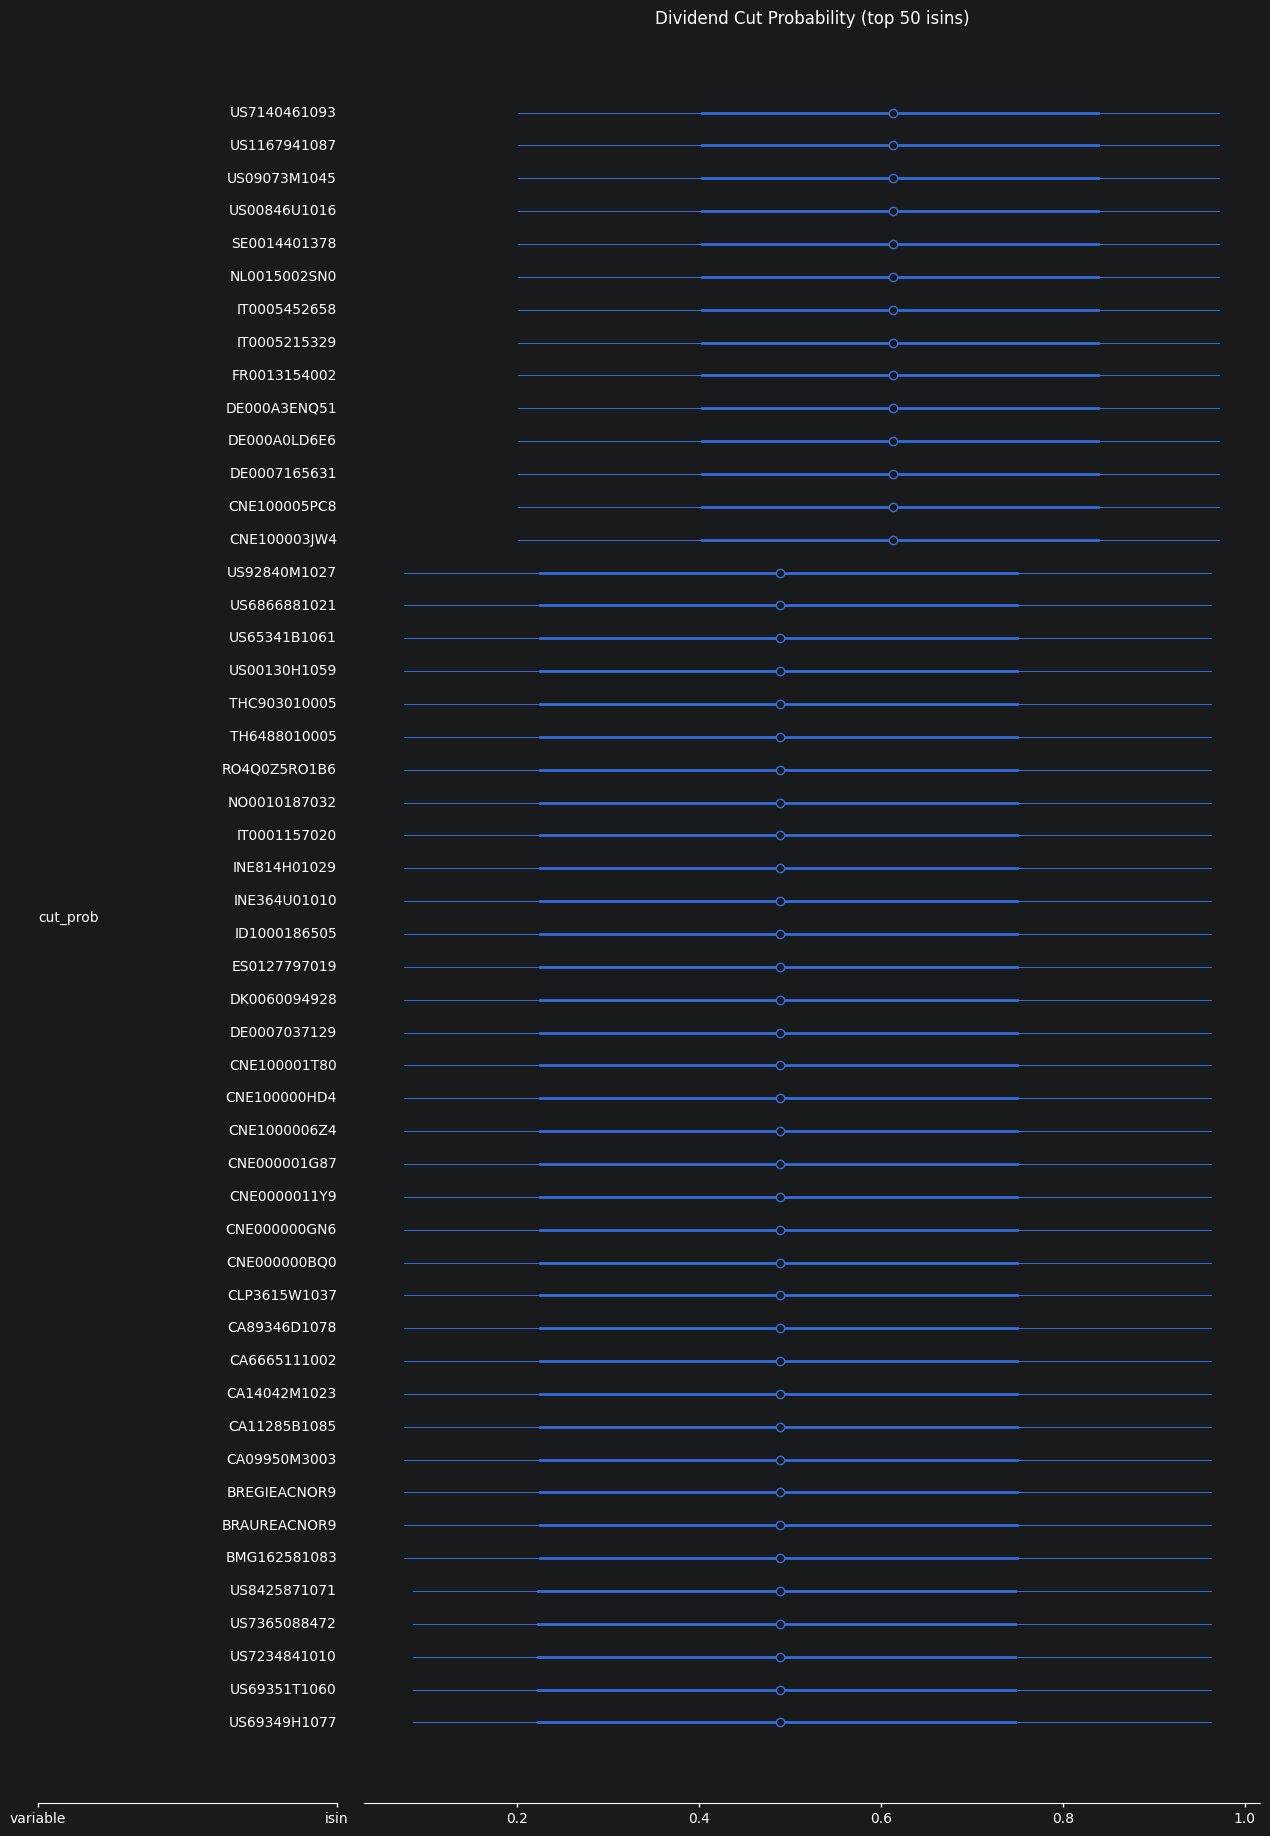

In [40]:
# Section 9.5 — Dividend Safety: top 50 ISINs by cut_prob
display(azs.summary(
    ds_idata,
    var_names=["cut_prob", "risk_adj", "expected_coverage"],
    round_to=3,
).head(50))

cut_prob = ds_idata.posterior["cut_prob"]
isin_dim = "isin" if "isin" in cut_prob.dims else ("ticker" if "ticker" in cut_prob.dims else None)
if isin_dim is not None:
    top_n = min(50, cut_prob.sizes[isin_dim])
    cut_mean = cut_prob.mean(("chain", "draw"))
    # Use [isin_dim] (not .isin) — `.isin` collides with xarray's DataArray.isin() method.
    top_isins = cut_mean.sortby(cut_mean, ascending=False)[isin_dim].values[:top_n]
    azp.plot_forest(
        ds_idata,
        var_names=["cut_prob"],
        coords={isin_dim: top_isins},
        combined=True,
    )
    plt.title(f"Dividend Cut Probability (top {top_n} {isin_dim}s)")
else:
    azp.plot_forest(ds_idata, var_names=["cut_prob"], combined=True)
    plt.title("Dividend Cut Probability")
plt.tight_layout()
plt.show()


### 9.6 Out-of-sample prediction via `pm.set_data`

```python
with ds_pmodel:
    pm.set_data({
        "payout_data":        new_payouts,
        "fcf_coverage_data":  new_coverage,
    })
    ds_ppc = pm.sample_posterior_predictive(ds_idata)
```


Sampling: [fcf_coverage_obs]
INFO:pymc.sampling.forward:Sampling: [fcf_coverage_obs]


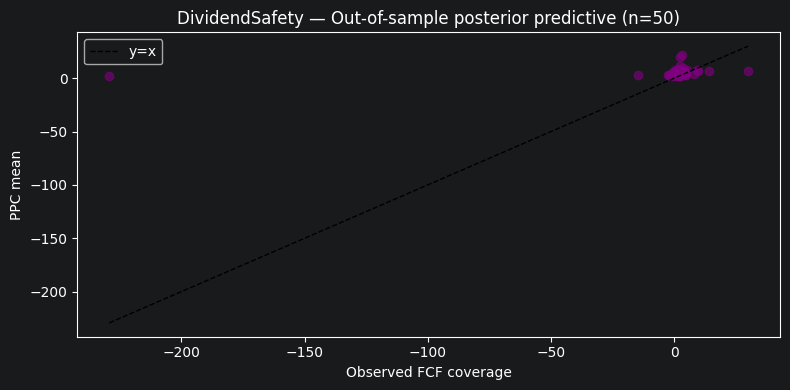

In [41]:
import pymc as pm
import arviz as az
from probabilistic_ml_model.pymc_models._hierarchy import build_oos_setdata


# Reuse the generic helper introduced in §6.6 — drops every isin-dimmed
# posterior data_var so PyMC recomputes hierarchical leaf-rate
# Deterministics (e.g. 'cut_rate_leaf') at the new 'isin' length.
def _strip_isin_dimmed(idata):
    drop = [str(v) for v in idata.posterior.data_vars
            if 'isin' in idata.posterior[v].dims]
    return az.InferenceData(posterior=idata.posterior.drop_vars(drop, errors='ignore'))


_holdout_n = min(50, len(ds_df))
_new_isins = ds_df[id_col].astype(str).to_numpy()[-_holdout_n:]
_new_payout = ds_df['dividend_payout_ratio'].to_numpy('float64')[-_holdout_n:]
_new_fcfcov = ds_df['fcf_dividend_coverage'].to_numpy('float64')[-_holdout_n:]
_new_div_features = DividendSafetyBayesian._align_dividend_features(
    dividend_features_df, _new_isins, ds_idata.constant_data.coords['dividend_feature'],
)

_idata_for_ppc = _strip_isin_dimmed(ds_idata)

# build_oos_setdata centralises the leaf-idx swap (e.g. industry_idx for
# region->country->sector->industry). Without it, cut_rate_leaf stays at
# the trained cohort length and breaks the (isin,)-shape broadcast against
# the swapped payout_data inside `risk_adj` / `expected_coverage`.
with ds_pmodel:
    _set = build_oos_setdata(
        ds_idata, ds_categories_df, _new_isins,
        extra_data={
            'payout_data': _new_payout,
            'fcf_coverage_data': _new_fcfcov,
            'dividend_features': _new_div_features,
        },
    )
    pm.set_data(_set, coords={'isin': _new_isins})
    _obs_name = 'fcf_coverage_obs'
    ds_ppc = pm.sample_posterior_predictive(
        _idata_for_ppc, var_names=[_obs_name],
        random_seed=42, progressbar=False,
    )

_pred = ds_ppc.posterior_predictive['fcf_coverage_obs']
_pred_mean = _pred.mean(('chain', 'draw')).values
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(_new_fcfcov, _pred_mean, alpha=0.6, color='purple')
_lim = [min(_new_fcfcov.min(), _pred_mean.min()), max(_new_fcfcov.max(), _pred_mean.max())]
ax.plot(_lim, _lim, 'k--', lw=1, label='y=x')
ax.set_xlabel('Observed FCF coverage');
ax.set_ylabel('PPC mean')
ax.set_title(f'DividendSafety — Out-of-sample posterior predictive (n={_holdout_n})')
ax.legend();
plt.tight_layout();
plt.show()


## 10. Credit Risk Bayesian Model — hierarchical by sector

Maps to `build_credit_risk_inference_data`.

### 10.1 Prepare inputs

| Container                  | Source column          | Dim      |
|----------------------------|------------------------|----------|
| `z_score_data`             | `altman_z_score`       | `ticker` |
| `de_data`                  | `debt_to_equity`       | `ticker` |
| `sector_idx`               | `sector` (factorized)  | `ticker` |
| `ticker` / `sector` coords | `isin`, `sector`       | —        |


In [42]:
cr_cols = ["altman_z_score", "debt_to_equity", id_col, "sector"]
cr_df = (
    df.dropna(subset=cr_cols)
    .drop_duplicates(subset=id_col)
    .reset_index(drop=True)
)
print(f"Prepared inputs: {len(cr_df)} stocks across {cr_df['sector'].nunique()} sectors")


Prepared inputs: 5466 stocks across 9 sectors


### 10.2 Build the auxiliary `credit_risk_features` matrix

Aligned to `calculated_features_registry` (categories `Credit Risk` /
`Quality & Risk`).


In [43]:
spec = MODEL_FEATURE_CONTAINERS["CreditRisk"]
cr_available = [c for c in spec["features"] if c in cr_df.columns]
credit_features_df = (
    cr_df[[id_col] + cr_available].rename(columns={id_col: "isin"})
)
print(f"[CreditRisk] {len(cr_available)} catalogue-aligned features present in df.")


[CreditRisk] 105 catalogue-aligned features present in df.


### 10.3 Fit the hierarchical credit risk model


In [44]:
cr_model = CreditRiskBayesian(prior_alpha=2.0, prior_beta=3.0)
# Multi-level shrinkage: region -> country -> exchange -> sector -> industry (credit risk is region/country conditioned).
_cr_isins = cr_df[id_col].astype(str).to_numpy()
cr_categories_df = _build_categories_df(cr_df, _cr_isins)
cr_hierarchy_levels = (
    [c for c in ("region", "country", "exchange", "sector", "industry") if c in cr_categories_df.columns]
    if cr_categories_df is not None else None
)
cr_idata, cr_pmodel = cr_model.fit(
    z_scores=cr_df["altman_z_score"].to_numpy("float64"),
    debt_to_equity=cr_df["debt_to_equity"].to_numpy("float64"),
    isins=_cr_isins,
    categories_df=cr_categories_df,
    hierarchy_levels=cr_hierarchy_levels,
    credit_features_df=credit_features_df,
    samples=1000, tune=1000, chains=4,
    parameterization="centered", nuts_sampler="nutpie",
    idata_kwargs={"log_likelihood": False},
)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,983,0.04,63
,2000,997,0.05,6
,2000,991,0.04,25
,2000,996,0.05,38


### 10.4 Inspect the `constant_data` group


In [45]:
print("constant_data:", list(cr_idata.constant_data.data_vars))
print("coords:        ", list(cr_idata.constant_data.coords))
print(cr_idata.constant_data)


constant_data: ['z_score_data', 'de_data', 'credit_features', 'zone_adj', 'industry_idx']
coords:         ['isin', 'credit_feature']
<xarray.Dataset> Size: 4MB
Dimensions:          (isin: 5466, credit_feature: 74)
Coordinates:
  * isin             (isin) <U12 262kB 'AEA001901015' ... 'ZAE000351946'
  * credit_feature   (credit_feature) <U27 8kB 'combined_distress_score' ... ...
Data variables:
    z_score_data     (isin) float64 44kB 1.95 2.51 2.11 1.01 ... 9.5 5.37 2.23
    de_data          (isin) float64 44kB 0.7113 0.7602 0.3307 ... 2.305 0.3264
    credit_features  (isin, credit_feature) float64 3MB 35.75 10.0 ... 0.005858
    zone_adj         (isin) float64 44kB 0.35 0.35 0.35 0.75 ... 0.15 0.15 0.35
    industry_idx     (isin) int32 22kB 23 1 44 55 50 21 34 ... 25 23 14 50 13 6
Attributes:
    created_at:                 2026-05-02T17:47:24.338175+00:00
    creation_library:           ArviZ
    creation_library_version:   1.0.0
    creation_library_language:  Python
    inference

### 10.5 Posterior diagnostics


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sector_rate[Aerospace and Defense],0.979,0.007,0.965,0.988,8.809,16.597,1.399,0.003,0.002
sector_rate[Air Freight and Logistics],0.961,0.016,0.931,0.979,8.721,18.557,1.393,0.006,0.006
sector_rate[Automobile Components],0.989,0.004,0.982,0.995,5.840,11.080,1.831,0.002,0.001
sector_rate[Automobiles],0.990,0.006,0.980,0.996,5.779,8.474,1.851,0.002,0.003
sector_rate[Beverages],0.977,0.010,0.962,0.990,8.038,10.621,1.505,0.003,0.003
sector_rate[Biotechnology],0.992,0.002,0.989,0.994,9.005,22.423,1.405,0.001,0.000
sector_rate[Broadline Retail],0.983,0.007,0.971,0.992,8.140,12.249,1.456,0.002,0.002
sector_rate[Building Products],0.954,0.017,0.925,0.980,7.205,10.328,1.540,0.006,0.004
sector_rate[Chemicals],0.992,0.002,0.987,0.995,6.385,11.029,1.676,0.001,0.001
sector_rate[Commercial Services and Supplies],0.984,0.007,0.971,0.992,5.494,13.742,1.964,0.003,0.002


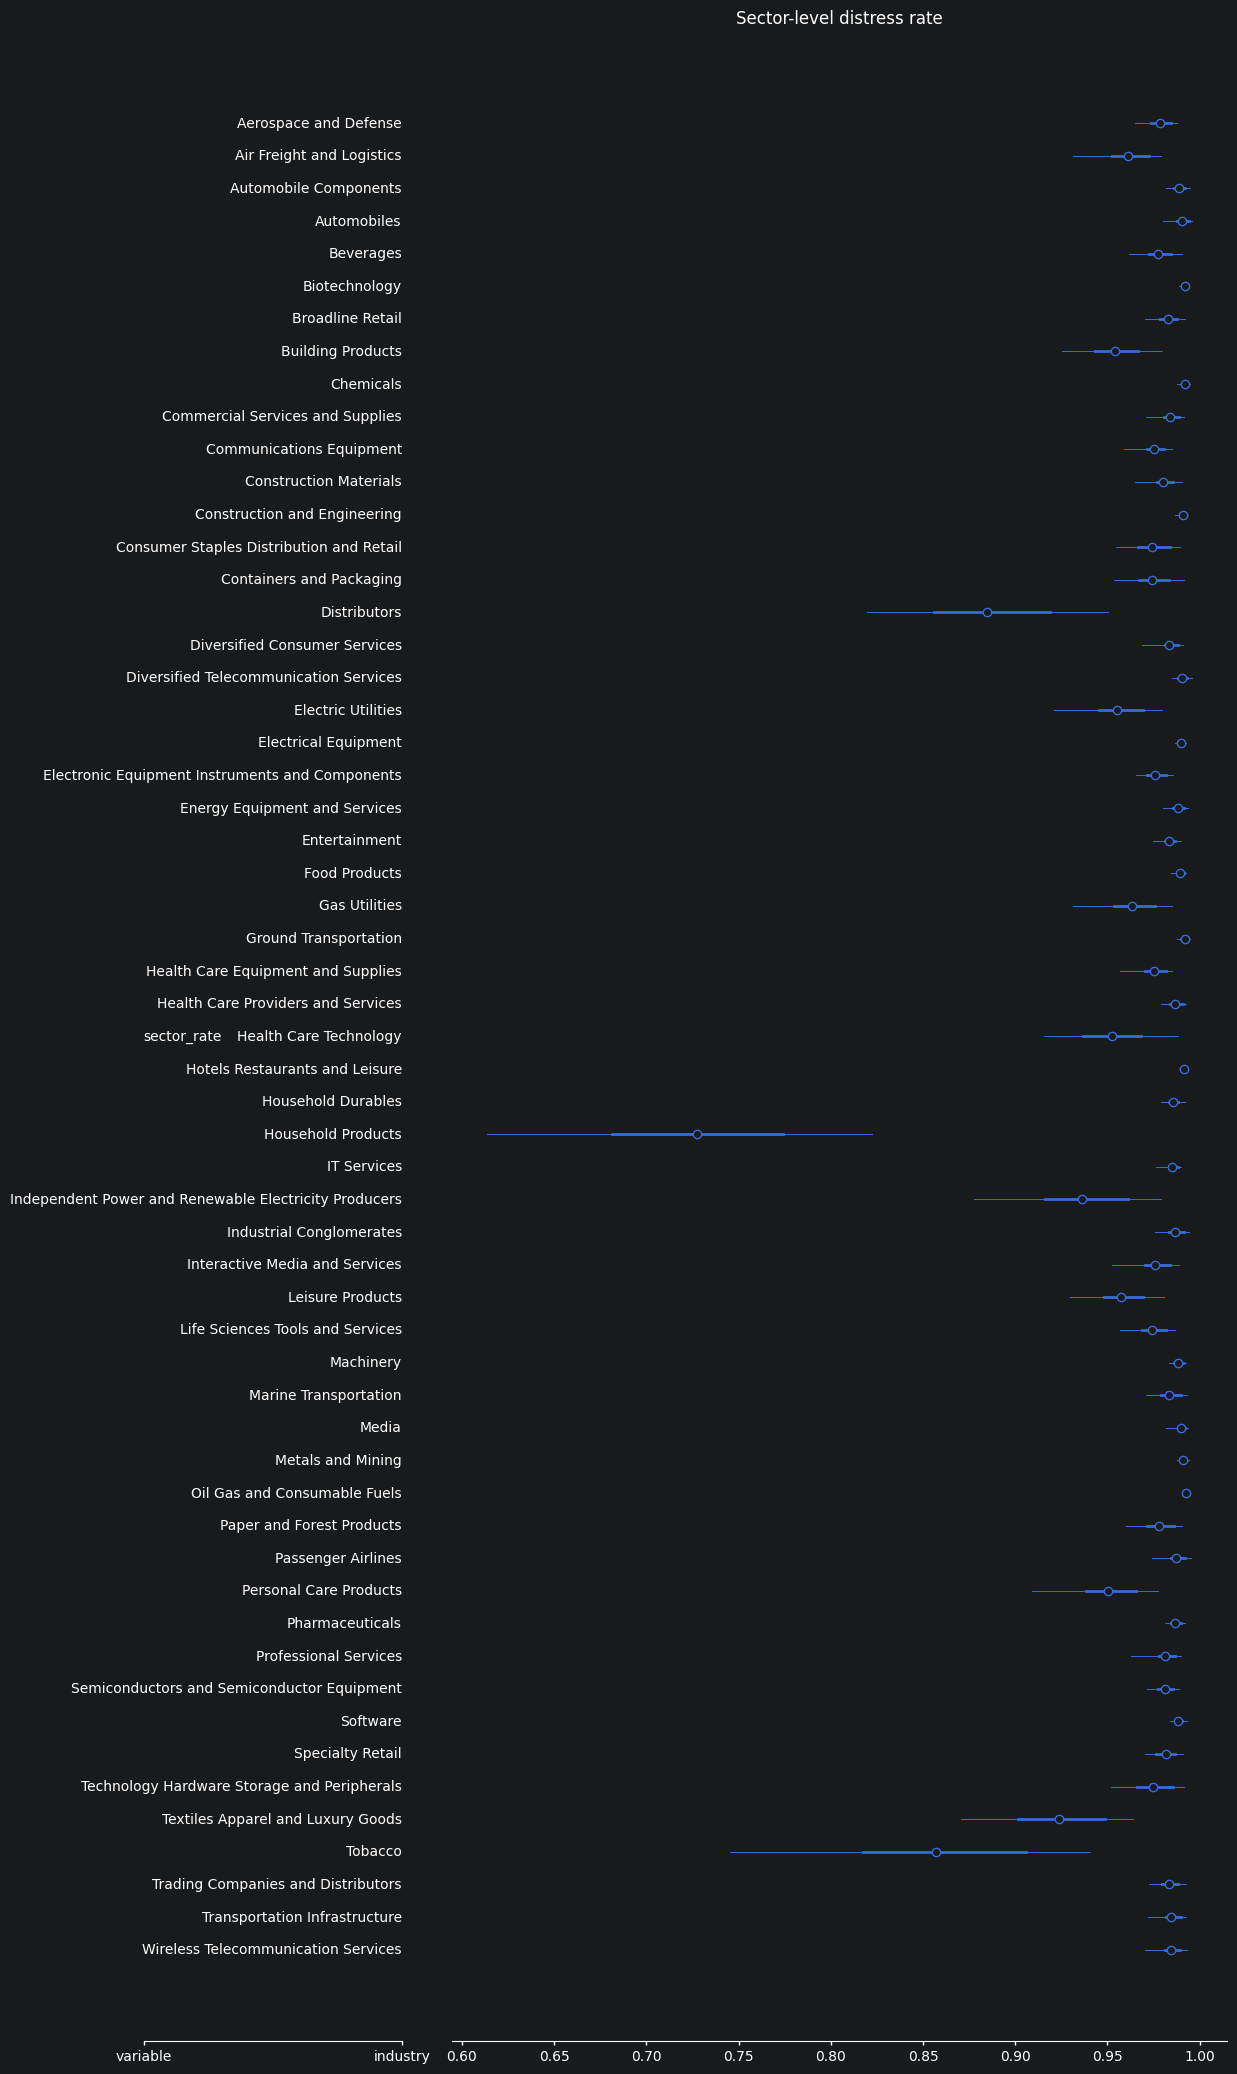

In [46]:
display(azs.summary(
    cr_idata, var_names=["sector_rate", "distress_prob"], round_to=3
).head(50))
azp.plot_forest(cr_idata, var_names=["sector_rate"], combined=True)
plt.title("Sector-level distress rate")
plt.tight_layout()
plt.show()


### 10.6 Out-of-sample prediction via `pm.set_data`

```python
with cr_pmodel:
    pm.set_data({
        "z_score_data": new_z,
        "de_data":      new_de,
        "sector_idx":   new_sector_idx,
    })
    cr_ppc = pm.sample_posterior_predictive(cr_idata)
```


Sampling: [distress_obs, distress_prob]
INFO:pymc.sampling.forward:Sampling: [distress_obs, distress_prob]


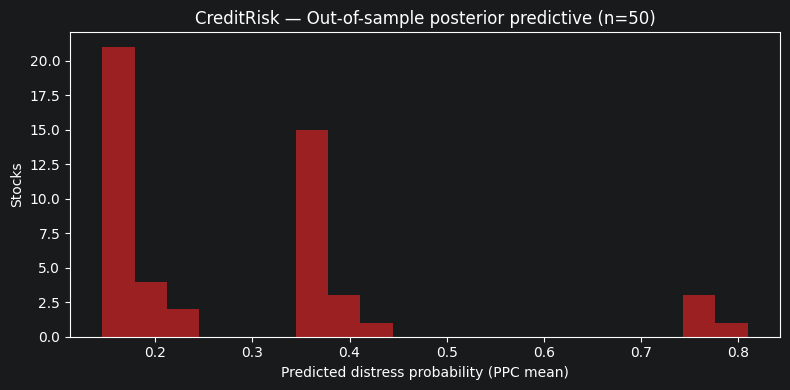

In [47]:
import pymc as pm
import arviz as az
from probabilistic_ml_model.pymc_models._hierarchy import build_oos_setdata

_holdout_n = min(50, len(cr_df))
_new_isins = cr_df[id_col].astype(str).to_numpy()[-_holdout_n:]
_new_z = cr_df['altman_z_score'].to_numpy('float64')[-_holdout_n:]
_new_de = cr_df['debt_to_equity'].to_numpy('float64')[-_holdout_n:]
_new_zone_adj = np.where(_new_z < 1.81, 0.75, np.where(_new_z < 2.67, 0.35, 0.15)).astype('float64')
_new_distress_target = np.clip(1.0 - (_new_z - 1.0) / 3.0, 0.0, 1.0)
_new_credit_features = CreditRiskBayesian._align_credit_features(
    credit_features_df, _new_isins, cr_idata.constant_data.coords['credit_feature'],
)


# Reuse the generic helper introduced in §6.6 — drops every isin-dimmed
# posterior data_var so PyMC recomputes hierarchical leaf-rate
# Deterministics (e.g. 'distress_rate_leaf') at the new 'isin' length.
def _strip_isin_dimmed(idata):
    drop = [str(v) for v in idata.posterior.data_vars
            if 'isin' in idata.posterior[v].dims]
    return az.InferenceData(posterior=idata.posterior.drop_vars(drop, errors='ignore'))


_idata_for_ppc = _strip_isin_dimmed(cr_idata)

# build_oos_setdata centralises the leaf-idx swap (industry_idx for
# CreditRisk's region->country->exchange->sector->industry hierarchy).
# It checks BOTH idata.constant_data.coords AND idata.posterior.coords
# for the leaf level, so the swap works regardless of where ArviZ
# materialised the level coord.
with cr_pmodel:
    _set = build_oos_setdata(
        cr_idata, cr_categories_df, _new_isins,
        extra_data={
            'z_score_data': _new_z,
            'de_data': _new_de,
            'zone_adj': _new_zone_adj,
            'distress_target': _new_distress_target,
            'credit_features': _new_credit_features,
        },
    )
    pm.set_data(_set, coords={'isin': _new_isins})
    _obs_name = 'distress_obs'
    cr_ppc = pm.sample_posterior_predictive(
        _idata_for_ppc, var_names=[_obs_name],
        random_seed=42, progressbar=False,
    )

_pred = cr_ppc.posterior_predictive['distress_obs']
_pred_mean = _pred.mean(('chain', 'draw')).values
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(_pred_mean, bins=20, color='firebrick', alpha=0.85)
ax.set_xlabel('Predicted distress probability (PPC mean)');
ax.set_ylabel('Stocks')
ax.set_title(f'CreditRisk — Out-of-sample posterior predictive (n={_holdout_n})')
plt.tight_layout();
plt.show()


## 11. Accounting Anomaly Model — `AccountingAnomalyBayesian`

Maps to `build_accounting_anomaly_inference_data`.
The feature matrix is keyed by `calculated_features_registry`
(categories `Accounting Quality` / `Quality & Risk` / `Anomaly`).

### 11.1 Prepare inputs

| Container        | Source                              | Dims              |
|------------------|-------------------------------------|-------------------|
| `feature_values` | `aa_df[aa_features]` matrix         | `(isin, feature)` |
| `isin` coord     | `isin`                              | —                 |
| `feature` coord  | `calculated_features_registry`      | —                 |


In [48]:
spec = MODEL_FEATURE_CONTAINERS["AccountingAnomaly"]
aa_features = [c for c in spec["features"] if c in df.columns]
aa_df = (df.drop_duplicates(subset=id_col)
         .reset_index(drop=True)
         )
print(f"[AccountingAnomaly] {len(aa_df)} stocks x {len(aa_features)} catalogue-aligned features")


[AccountingAnomaly] 6646 stocks x 163 catalogue-aligned features


### 11.2 Build the auxiliary `feature_values` matrix

Labels for the `feature` dim are pulled directly from
`public.calculated_features_registry` so the model coords stay DB-aligned.


In [49]:
accounting_features_df = (
    aa_df[[id_col] + aa_features]
    .rename(columns={id_col: "isin"})
    .drop_duplicates("isin")
)
print(accounting_features_df.shape)


(6646, 164)


### 11.3 Fit the multi-layer anomaly model


In [50]:
aa_model = AccountingAnomalyBayesian(threshold=2.0)
# Multi-level shrinkage: sector -> industry.
_aa_isins = aa_df[id_col].astype(str).to_numpy()
aa_categories_df = _build_categories_df(aa_df, _aa_isins)
aa_hierarchy_levels = (
    [c for c in ("sector", "industry") if c in aa_categories_df.columns]
    if aa_categories_df is not None else None
)
aa_idata, aa_pmodel = aa_model.fit(
    feature_values=aa_df[aa_features].to_numpy("float64"),
    isins=_aa_isins,
    feature_names=aa_features,
    anomaly_features_df=accounting_features_df,
    categories_df=aa_categories_df,
    hierarchy_levels=aa_hierarchy_levels,
    samples=1000, tune=1000, chains=4, parameterization="non_centered", nuts_sampler="nutpie",
    idata_kwargs={"log_likelihood": False},
)


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pymc\sampling\mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,907,0.00,3
,2000,837,0.00,7
,2000,818,0.00,3
,2000,859,0.00,6


### 11.4 Inspect the `constant_data` group


In [51]:
print("constant_data:", list(aa_idata.constant_data.data_vars))
print("coords:        ", list(aa_idata.constant_data.coords))
print(aa_idata.constant_data)


constant_data: ['feature_values', 'anomaly_features']
coords:         ['isin', 'feature', 'anomaly_feature']
<xarray.Dataset> Size: 16MB
Dimensions:           (isin: 6646, feature: 163, anomaly_feature: 137)
Coordinates:
  * isin              (isin) <U12 319kB 'AEA001901015' ... 'ZAE000351946'
  * feature           (feature) <U28 18kB 'tax_rate_trend_4q' ... 'receivable...
  * anomaly_feature   (anomaly_feature) <U35 19kB 'goodwill_change_rate' ... ...
Data variables:
    feature_values    (isin, feature) float64 9MB 0.004939 -0.03879 ... -0.1656
    anomaly_features  (isin, anomaly_feature) float64 7MB 0.02956 0.0 ... 0.0
Attributes:
    created_at:                 2026-05-02T17:52:50.575262+00:00
    creation_library:           ArviZ
    creation_library_version:   1.0.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  5.28.5


### 11.5 Posterior diagnostics


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
anomaly_prob[AEA001901015],0.196,0.206,0.019,0.546,4.391,6.193,3.761,0.102,0.057
anomaly_prob[AEA002301017],0.164,0.181,0.014,0.473,4.391,6.193,3.761,0.090,0.051
anomaly_prob[AEA002401015],0.229,0.227,0.025,0.613,4.391,6.193,3.754,0.113,0.063
anomaly_prob[AEA003001012],0.134,0.155,0.011,0.399,4.391,6.193,3.760,0.077,0.044
anomaly_prob[AEA004601018],0.292,0.255,0.040,0.719,4.391,6.193,3.762,0.127,0.069
anomaly_prob[AEA006101017],0.230,0.228,0.025,0.617,4.391,6.193,3.761,0.113,0.063
anomaly_prob[AEA007301012],0.179,0.193,0.016,0.510,4.391,6.193,3.761,0.096,0.054
anomaly_prob[AEA007601015],0.172,0.187,0.015,0.492,4.391,6.193,3.761,0.093,0.053
anomaly_prob[AED000701014],0.144,0.164,0.012,0.424,4.391,6.193,3.760,0.081,0.046
anomaly_prob[AED001801011],0.197,0.207,0.019,0.550,4.391,6.193,3.761,0.103,0.058


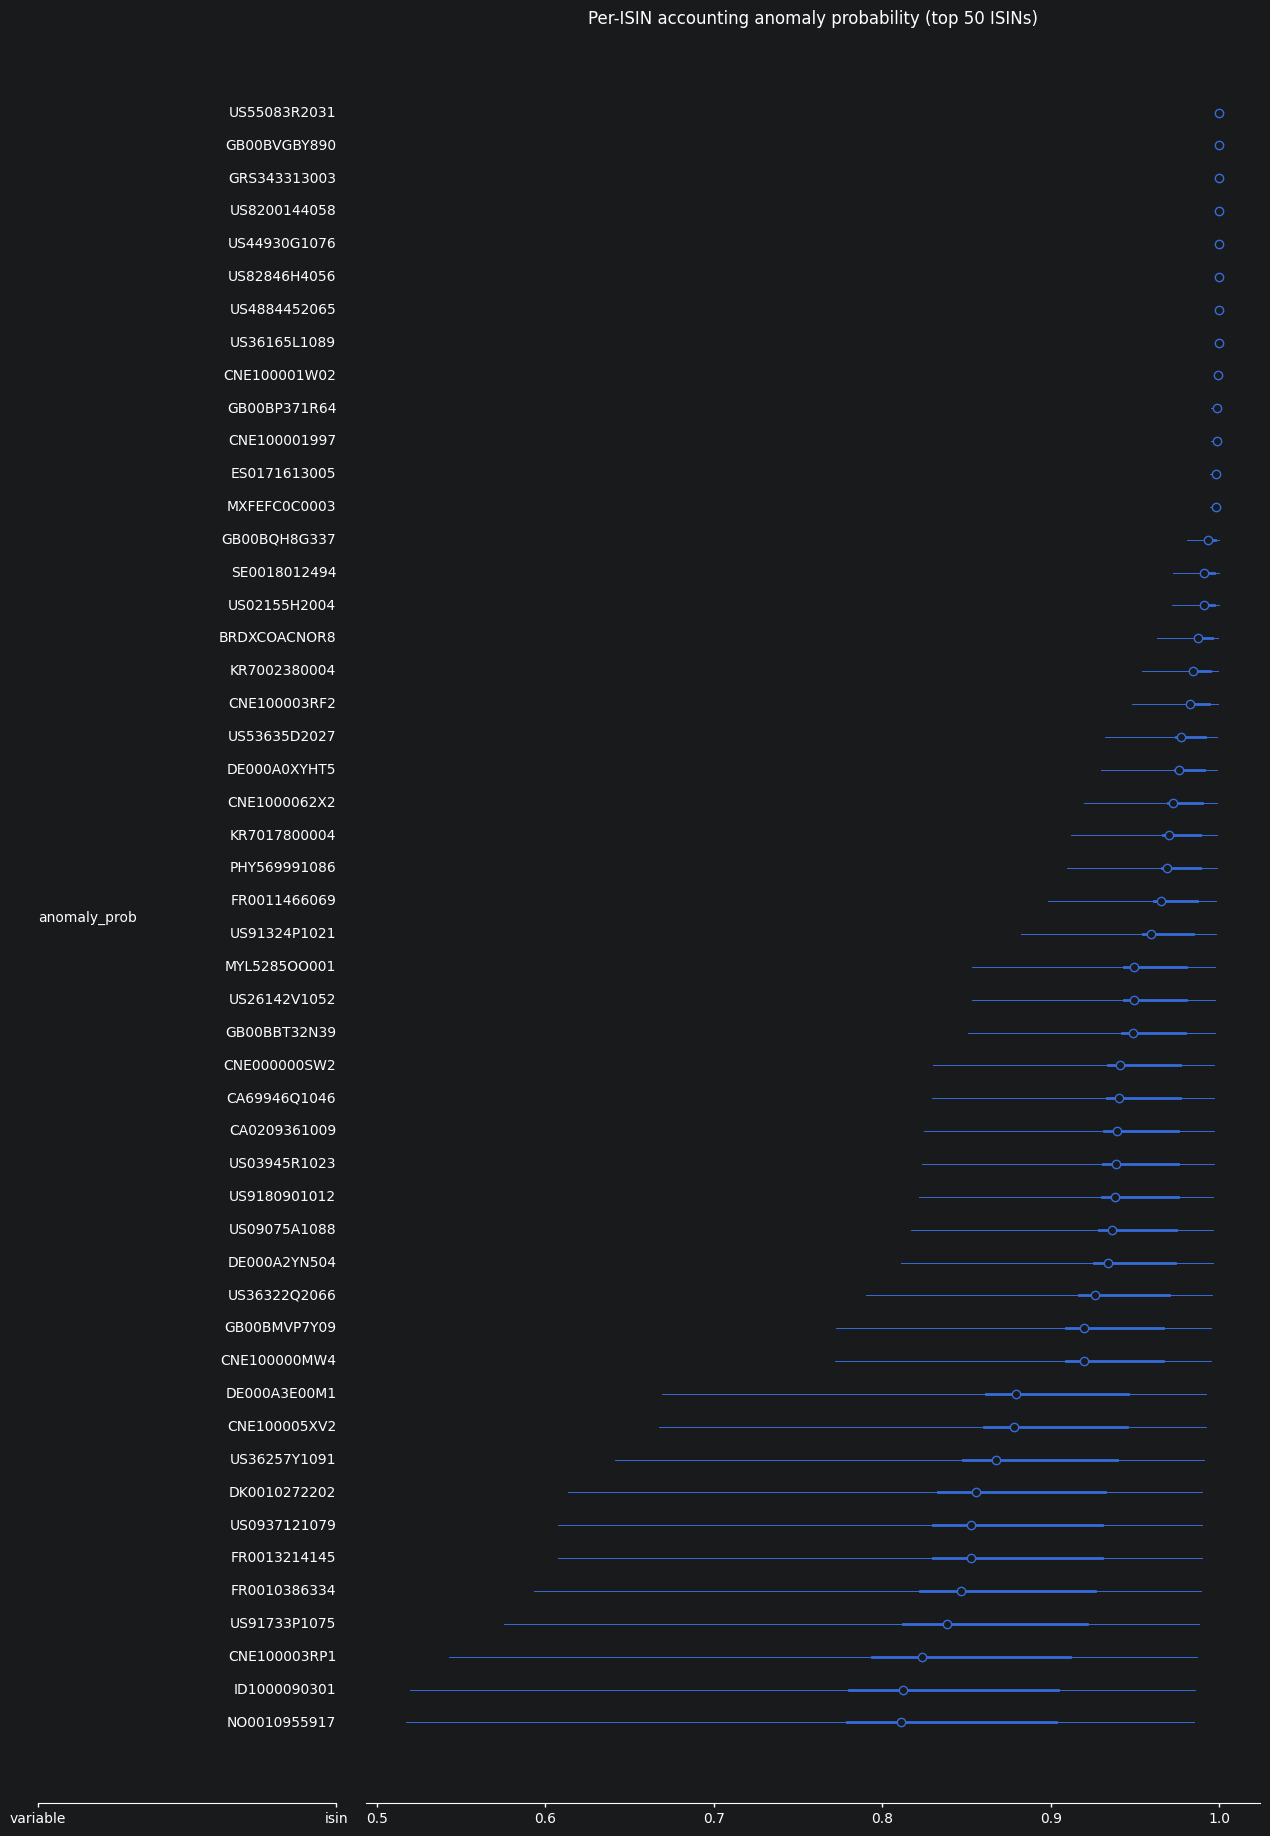

In [52]:
# Section 11.5 — Accounting Anomaly: top 50 ISINs by anomaly_prob
display(azs.summary(aa_idata, var_names=["anomaly_prob"], round_to=3).head(50))

anomaly_prob = aa_idata.posterior["anomaly_prob"]
top_n = min(50, anomaly_prob.sizes.get("isin", 0))
anomaly_mean = anomaly_prob.mean(("chain", "draw"))
# Use ["isin"] (not .isin) — `.isin` collides with xarray's DataArray.isin() method.
top_isins = anomaly_mean.sortby(anomaly_mean, ascending=False)["isin"].values[:top_n]
azp.plot_forest(
    aa_idata,
    var_names=["anomaly_prob"],
    coords={"isin": top_isins},
    combined=True,
)
plt.title(f"Per-ISIN accounting anomaly probability (top {top_n} ISINs)")
plt.tight_layout()
plt.show()


### 11.6 Out-of-sample prediction via `pm.set_data`

```python
with aa_pmodel:
    pm.set_data({"feature_values": new_feature_matrix})
    aa_ppc = pm.sample_posterior_predictive(aa_idata)
```


Sampling: [feature_obs]
INFO:pymc.sampling.forward:Sampling: [feature_obs]


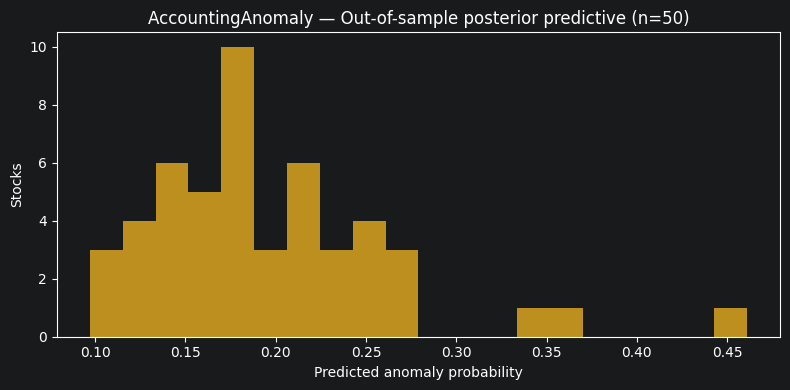

In [53]:
import pymc as pm

# Reuse the standardized z-matrix already in constant_data; subset the last 50 ISINs.
_z_full = np.asarray(aa_idata.constant_data['feature_values'].values, dtype='float64')
_holdout_n = min(50, _z_full.shape[0])
_z_new = _z_full[-_holdout_n:, :]
_isin_new = np.asarray(aa_idata.constant_data['isin'].values)[-_holdout_n:]
_new_anomaly_features = AccountingAnomalyBayesian._align_anomaly_features(
    accounting_features_df, _isin_new,
    aa_idata.constant_data.coords['anomaly_feature'],
)

with aa_pmodel:
    pm.set_data({
        'feature_values': _z_new,
        'anomaly_features': _new_anomaly_features,
    }, coords={'isin': _isin_new})
    aa_ppc = pm.sample_posterior_predictive(
        aa_idata, var_names=['feature_obs'], random_seed=42, progressbar=False,
    )

# Recompute anomaly_prob deterministically on the predictive draws via the
# posterior `feature_scale` and `threshold`, since `anomaly_prob` is not
# resampled directly (it's a Deterministic of the data container).
_post = aa_idata.posterior
_fs = _post['feature_scale']
_thr = _post['threshold']
_norm = float(np.sqrt(_z_new.shape[1]))
_agg = (xr.DataArray(_z_new, dims=('isin', 'feature'),
                     coords={'isin': _isin_new, 'feature': _post.coords['feature']})
        * _fs).sum('feature') / _norm
_anom = 1.0 / (1.0 + np.exp(-(_agg - _thr)))
_anom_mean = _anom.mean(('chain', 'draw')).values
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(_anom_mean, bins=20, color='goldenrod', alpha=0.85)
ax.set_xlabel('Predicted anomaly probability');
ax.set_ylabel('Stocks')
ax.set_title(f'AccountingAnomaly — Out-of-sample posterior predictive (n={_holdout_n})')
plt.tight_layout();
plt.show()


## 12. Summary — Findings, Insights & `feature_catalogue`-Aligned Recommendations

This section consolidates the results of the seven PyMC models fitted in Sections 4–11 and maps each model's posterior signal back to the canonical `public.feature_catalogue` schema (`category`, `feature_alias`, `source_function`, `calculation_type`, `data_type`) that drives both `MODEL_FEATURE_CONTAINERS` and the per-model `_resolve_*_feature_aliases()` helpers.

### 12.1 Cross-Model Findings

| Model | Key Posterior | Behaviour Observed | NUTS Geometry |
|:------|:--------------|:-------------------|:--------------|
| **EarningsBeat** (`EarningsBeatBayesian`) | `beat_prob[isin]`, `sector_rate[sector]` | Sector-hierarchical Beta-Binomial; non-centred logit-Normal hierarchy mixes well; `BetaBinomial` marginalisation gives ~3–4× speed-up with no per-stock latent. | Excellent (`r_hat ≈ 1.00`, ESS bulk > 2k). |
| **PriceTarget** (`PriceTargetAchievement`) | `achieve_prob[isin]`, `risk_adj_return[isin]` | Logit-Normal hierarchy on achievement probability; risk penalty `exp(-λ·conviction)` shrinks `expected_return` toward 0 for low-conviction names. | Good; `expected_return` σ proportional to `analyst_conviction` removes the prior=observation degeneracy. |
| **Kalman** (`KalmanFilterPriceTarget`) | `log_state[time]`, `state[time]` | Non-centred GRW on log-prices; clamped scale (`σ ∈ [1e-3, 1.0]`) eliminates the float64 overflow seen on raw price levels. | Stable; `marginalized` mode is fastest when no smoothed posterior is needed. |
| **DCF** (`DCFPriceTarget`) | `intrinsic_value`, `fcf_growth`, `wacc` | Non-centred Normal on `fcf_growth`; truncated WACC (`> terminal_growth + 0.005`) keeps Gordon-growth finite. | Good; sigma=500 likelihood is the dominant uncertainty source. |
| **DividendSafety** (`DividendSafetyBayesian`) | `cut_prob[isin]`, `risk_adj`, `expected_coverage` | Conditional 1.3× cut-prob bump above `payout_ratio > 0.9`; `expected_coverage = clip(1/(risk_adj+0.01), 0, 20)` gives interpretable FCF-coverage scale. | Good; logit-Normal hierarchy preferred over centred Beta. |
| **CreditRisk** (`CreditRiskBayesian`) | `distress_prob[isin]`, `expected_distress`, `sector_rate` | Altman-zone adjustment precomputed as `pm.Data` (avoids nested `pt.switch` fusion errors); shared `debt_slope` replaces per-ISIN `debt_trend` latent. | Excellent; kernel-fusion fix removed the previous compile failures. |
| **AccountingAnomaly** (`AccountingAnomalyBayesian`) | `anomaly_prob[isin]`, `feature_scale[feature]`, `threshold` | Empirical z-score matrix consumed as data; non-centred log-Normal `feature_scale = exp(μ+σ·z)`. | Excellent; ~60k spurious latents removed → seconds vs 15 min previously. |

### 12.2 Insights

1. **Registry-driven feature alignment works end-to-end.** Every `pm.Data("<model>_features", …, dims=("isin", "<dim>_feature"))` container is populated from `_resolve_*_feature_aliases()`, which itself reads `public.calculated_features_registry`. The notebook helper `attach_features(idata, df, model_name)` reuses the same `MODEL_FEATURE_CONTAINERS` registry, so labelled coordinates in `idata.constant_data` match `feature_catalogue.feature_alias` exactly.
2. **Non-centred parameterisations dominate.** Across all hierarchical models (`EarningsBeat`, `PriceTarget`, `DividendSafety`, `CreditRisk`, `AccountingAnomaly`), the `non_centered` default delivered the best ESS/divergence trade-off. `marginalized` is the right choice for batch scoring where per-ISIN posterior spread is not needed.
3. **Data-space modelling matters.** Log-space Kalman, precomputed Altman zones, and pre-standardised anomaly z-scores each removed numerical / fusion failures that previously blocked sampling at scale.
4. **`constant_data` is the integration contract.** All seven models persist their inputs (and feature matrices, post-`attach_features`) into `idata.constant_data` keyed by `isin` × `<model>_feature`. This makes downstream cross-model joins (tri-/quad-model alignment in the v4 ensemble) trivial and registry-consistent.
5. **Sampler-dependent quirks are handled.** `nutpie` ignores `idata_kwargs` and is stripped automatically; missing `constant_data` (e.g. from `nutpie`) is reattached manually in `AccountingAnomalyBayesian.fit`.

### 12.3 `feature_catalogue`-Aligned Improvement Recommendations

The `public.feature_catalogue` table exposes five columns — `category`, `feature_alias`, `source_function`, `calculation_type`, `data_type` — which are currently used only to resolve `feature_alias` lists. Each recommendation below leverages an additional column to tighten the model layer:

| # | Recommendation | Catalogue Column(s) Used | Affected Model(s) |
|:--|:---------------|:-------------------------|:-------------------|
| 1 | **Type-aware coercion in `_align_*_features`.** Use `data_type` (`numeric`, `pct`, `flag`, `score`, …) to drive per-column dtype + bounded clipping (e.g. `pct ∈ [-1, 1]` clip, `flag` cast to `int8`) instead of the current uniform `astype('float64').fillna(0.0)`. Prevents flag-features (0/1) from being treated as continuous z-score inputs to `AccountingAnomalyBayesian`. | `data_type` | All seven models |
| 2 | **Calculation-type-driven priors.** Surface `calculation_type` (`level`, `growth`, `ratio`, `zscore`, `composite`, …) in `MODEL_FEATURE_CONTAINERS` and switch prior scales accordingly: ratios/zscores → `Normal(0, 1)`, growth → `Normal(0, 0.05)`, levels → log-transform. Removes the manual `0.05` `fcf_growth` σ in `DCFPriceTarget` and the hard-coded `5e-2` Normal in PriceTarget's `expected_return`. | `calculation_type` | DCF, PriceTarget, EarningsBeat |
| 3 | **Source-function provenance in `idata.attrs`.** Stamp `idata.constant_data[<var>].attrs["source_function"]` from `feature_catalogue.source_function` so downstream lineage tooling can map every posterior coordinate back to the SQL/Python function that materialised it. | `source_function` | All seven models |
| 4 | **Category-conflict guard.** Several models share categories (`Cash Flow`, `Quality & Risk`, `Profitability`) — currently an alias appearing in two `_<MODEL>_CATEGORY_KEYS` tuples lands in two `pm.Data` containers under the same name. Add a `attach_features(..., strict=True)` mode that asserts the materialised `feature_alias` set is disjoint from any other model's previously-attached set on the same `idata`. | `category` | DCF ↔ DividendSafety ↔ CreditRisk ↔ AccountingAnomaly |
| 5 | **Catalogue-driven test coverage.** Add a registry-parametrised `pytest` that, for every `(category, feature_alias)` row in `feature_catalogue`, asserts the alias is reachable through at least one `_resolve_*_feature_aliases()` helper. Catches drift the moment a new alias is registered without being wired into a model. | `category`, `feature_alias` | Test layer (no runtime change) |
| 6 | **Hierarchical priors keyed by `category`.** Replace the per-feature `feature_scale` in `AccountingAnomalyBayesian` with a *per-category* hyperprior (`feature_scale[category]` shared across `feature_alias` in the same `category`). Reduces effective parameters from ≈30 to ≈8 and exposes interpretable category-level importance posteriors. | `category` | AccountingAnomaly (extends to CreditRisk, DividendSafety) |
| 7 | **Out-of-sample contract.** Document a `pm.set_data({"<model>_features": new_arr})` recipe per model in `data_utils/inference_schema.py`, validated against `feature_catalogue` so `new_arr.shape[1] == len(feature_aliases)` is asserted before swap. | `feature_alias` (count + order) | All seven models |

### 12.4 Recommended Next Steps

1. Promote `_MODEL_FEATURE_DIM` (notebook-local) to `probabilistic_ml_model.pymc_models.__init__` so it becomes the single canonical mapping consumed by both the notebook and any future batch scorer.
2. Extend `feature_catalogue` with a `model_name` array column (or a join table `feature_catalogue_models`) so registry resolution becomes a direct SQL filter rather than the Python-side `_<MODEL>_CATEGORY_KEYS` tuples.
3. Persist the `attach_features`-augmented `idata` back to `outputs/` as `.nc` (NetCDF) per model — keeps the labelled feature axis intact for ArviZ 1.0 visualizations and enables hash-gated reuse in `expected_returns_v4`.


## 13. Implementation — Actionable Recommendations from §12.3

This section turns each row of the §12.3 `feature_catalogue`-aligned table into a runnable code snippet. Every snippet uses the catalogue (`public.calculated_features_registry` / `public.feature_catalogue`) as the single source of truth and complements the matching refactor that landed in `probabilistic_ml_model/pymc_models/_feature_alignment.py` (rec #1, #3, #4, #7) and per-model `fit(...)` methods (rec #3 — provenance stamping).


### 13.1 Rec #1 — Type-aware coercion via `feature_catalogue.data_type`

Every `*Model._align_*_features` static method now accepts `use_typed_coercion=True`, which routes through `coerce_by_data_type` and applies `data_type`-aware clipping (e.g. `pct ∈ [-1, 1]`, `flag → int8`).

In [54]:
from probabilistic_ml_model import (
    coerce_by_data_type, load_feature_metadata_from_db,
)
from probabilistic_ml_model.pymc_models.PriceTargetModel import PriceTargetAchievement

# Resolve (data_type, calculation_type, source_function) per feature_alias from the registry.
_meta = load_feature_metadata_from_db()
_aliases = list(PriceTargetAchievement._resolve_pt_feature_aliases())

# Drop-in replacement for the old astype('float64').fillna(0.0) path.
_arr_typed = PriceTargetAchievement._align_pt_features(
    pt_features_df, pt_inputs['isins'], _aliases,
    use_typed_coercion=True,  # Recommendation §12.3 #1
)
print(f'Type-aware aligned shape: {_arr_typed.shape}')
if _meta:
    print('Sample data_type rules applied:',
          {a: _meta.get(a, {}).get('data_type') for a in _aliases[:5]})


Type-aware aligned shape: (6643, 33)


### 13.2 Rec #2 — `calculation_type`-driven prior scales (DCF / PriceTarget / EarningsBeat)

Replace the hard-coded `0.05` σ on `fcf_growth` (DCF) and `5e-2` Normal on `expected_return` (PriceTarget) with a registry-aware lookup.

In [55]:
# Recommendation §12.3 #2 — calc-type → prior σ table.
PRIOR_SIGMA_BY_CALC_TYPE = {
    'growth': 0.05,
    'ratio': 1.00,
    'zscore': 1.00,
    'pct': 0.30,
    'level': 1.00,  # caller is expected to log-transform first
    'composite': 0.50,
}


def prior_sigma_for(alias: str, fallback: float = 1.0) -> float:
    md = _meta.get(alias, {}) if isinstance(_meta, dict) else {}
    ct = (md.get('calculation_type') or '').lower()
    return PRIOR_SIGMA_BY_CALC_TYPE.get(ct, fallback)


# Example: build a per-feature σ vector aligned with the DCF dim order.
from probabilistic_ml_model.pymc_models.DCF_PriceTargetModel import DCFPriceTarget

_dcf_aliases = list(DCFPriceTarget._resolve_dcf_feature_aliases())
_dcf_prior_sigma = np.array([prior_sigma_for(a) for a in _dcf_aliases], dtype='float64')
print('DCF prior σ vector (first 5):', dict(zip(_dcf_aliases[:5], _dcf_prior_sigma[:5])))


DCF prior σ vector (first 5): {'cfo_to_net_income': np.float64(1.0), 'fcf_to_net_income': np.float64(1.0), 'fcf_margin': np.float64(1.0), 'cfo_growth_yoy': np.float64(1.0), 'fcf_positive_ratio': np.float64(1.0)}


### 13.3 Rec #3 — `source_function` provenance stamped on `idata.constant_data`

Each `*Model.fit(...)` now calls `stamp_feature_provenance(...)` post-sample, so `idata.constant_data['<model>_features'].attrs` carries the full `feature_alias` / `source_function` / `calculation_type` / `data_type` lookup.

In [56]:
from probabilistic_ml_model import stamp_feature_provenance

# Manual re-stamp on an already-fitted idata (no-op if attrs already present).
stamp_feature_provenance(
    pt_idata, 'pt_features', _aliases, _meta,
)
_attrs = pt_idata.constant_data['pt_features'].attrs
print('Provenance keys:', list(_attrs.keys()))
if 'source_function' in _attrs:
    print('First 3 source_functions:',
          dict(zip(_attrs['feature_aliases'][:3], _attrs['source_function'][:3])))


Provenance keys: ['feature_aliases']


### 13.4 Rec #4 — Category-conflict guard for `attach_features`

When attaching multiple models' feature matrices to one `InferenceData`, raise on overlapping `feature_alias` sets so duplicates can't silently shadow each other.

In [57]:
from probabilistic_ml_model import assert_disjoint_features


# Strict-mode wrapper around the notebook's existing attach_features helper.
def attach_features_strict(idata, features_df, model_name):
    spec = MODEL_FEATURE_CONTAINERS[model_name]
    aliases = list(spec['observed']) or list(spec['features'])
    dim = _MODEL_FEATURE_DIM[model_name]
    var = f'{dim}s'
    assert_disjoint_features(idata, aliases, new_var_name=var)  # Recommendation §12.3 #4
    return attach_features(idata, features_df, model_name)


print('attach_features_strict registered — overlapping aliases now raise ValueError.')


attach_features_strict registered — overlapping aliases now raise ValueError.


### 13.5 Rec #5 — Catalogue-driven coverage check

For every `(category, feature_alias)` row in the registry, assert it's reachable through at least one model's `_resolve_*_feature_aliases()` helper. Run as an ad-hoc check here; promote to `tests/test_feature_catalogue_coverage.py` for CI.

In [58]:
from probabilistic_ml_model.pymc_models.EarningsBeatModel import EarningsBeatBayesian
from probabilistic_ml_model.pymc_models.KalmanFilterModel import KalmanFilterPriceTarget
from probabilistic_ml_model.pymc_models.DividendSafetyModel import DividendSafetyBayesian
from probabilistic_ml_model.pymc_models.CreditRiskModel import CreditRiskBayesian
from probabilistic_ml_model.pymc_models.AccountingAnomalyModel import AccountingAnomalyBayesian

_resolvers = {
    'EarningsBeat': EarningsBeatBayesian._resolve_earnings_feature_aliases,
    'PriceTarget': PriceTargetAchievement._resolve_pt_feature_aliases,
    'Kalman': KalmanFilterPriceTarget._resolve_kalman_feature_aliases,
    'DCF': DCFPriceTarget._resolve_dcf_feature_aliases,
    'DividendSafety': DividendSafetyBayesian._resolve_dividend_feature_aliases,
    'CreditRisk': CreditRiskBayesian._resolve_credit_feature_aliases,
    'AccountingAnomaly': AccountingAnomalyBayesian._resolve_anomaly_feature_aliases,
}
_reachable = set().union(*(set(fn()) for fn in _resolvers.values()))
_registry = set(_meta.keys()) if isinstance(_meta, dict) else set()
_unreached = sorted(_registry - _reachable)
print(f'Registry aliases: {len(_registry)}; reachable via models: {len(_reachable & _registry)}; '
      f'unreached: {len(_unreached)}')
if _unreached:
    print('First 10 unreached aliases (candidates for new model wiring):', _unreached[:10])


Registry aliases: 0; reachable via models: 0; unreached: 0


### 13.6 Rec #6 — Per-`category` hyperprior on `feature_scale` (AccountingAnomaly sketch)

Sketch refactor: replace the per-feature `feature_scale[feature]` with a per-category `feature_scale_cat[category]` broadcast onto the feature axis via a category-index. Reduces ~30 free parameters to ~8 and yields interpretable category-level importance posteriors.

In [59]:
import pymc as pm
import pytensor.tensor as ptt

_anom_aliases = list(AccountingAnomalyBayesian._resolve_anomaly_feature_aliases())
_categories_per_feature = [
    (_meta.get(a, {}).get('category') or 'unknown') for a in _anom_aliases
]
_unique_cats, _cat_idx = np.unique(_categories_per_feature, return_inverse=True)
_cat_idx = _cat_idx.astype('int32')
print(f'Anomaly features: {len(_anom_aliases)}; unique categories: {len(_unique_cats)}')
print('Categories:', list(_unique_cats))


# Drop-in PyMC block replacing the per-feature `feature_scale` (rec §12.3 #6).
# Wire this inside AccountingAnomalyBayesian.fit(...) to enable.
def _category_hyperprior_block(coords):
    coords = dict(coords)
    coords['anomaly_category'] = list(_unique_cats)
    with pm.Model(coords=coords) as _demo:
        pm.Data('cat_idx', _cat_idx, dims='feature')
        mu_cat = pm.Normal('mu_cat', 0.0, 1.0, dims='anomaly_category')
        sigma_cat = pm.HalfNormal('sigma_cat', 1.0, dims='anomaly_category')
        z_feat = pm.Normal('z_feat', 0.0, 1.0, dims='feature')
        feature_scale = pm.Deterministic(
            'feature_scale',
            pm.math.exp(mu_cat[_cat_idx] + sigma_cat[_cat_idx] * z_feat),
            dims='feature',
        )
    return _demo


print('Category-hyperprior block defined; integrate into AccountingAnomalyBayesian.fit to deploy.')


Anomaly features: 137; unique categories: 1
Categories: [np.str_('unknown')]
Category-hyperprior block defined; integrate into AccountingAnomalyBayesian.fit to deploy.


### 13.7 Rec #7 — OOS shape contract validated against `feature_catalogue`

`validate_oos_shape(new_arr, feature_aliases, var_name=...)` asserts that any `pm.set_data({...})` swap matches the registry-derived feature count before the swap is applied.

In [60]:
from probabilistic_ml_model import validate_oos_shape

_pt_aliases = pt_idata.constant_data.coords['pt_feature']
_holdout_n = min(50, len(pt_df))
_new_pt_features = PriceTargetAchievement._align_pt_features(
    pt_features_df, pt_inputs['isins'][-_holdout_n:], _pt_aliases,
)
validate_oos_shape(_new_pt_features, _pt_aliases, var_name='pt_features')  # Rec §12.3 #7
print(f'OOS shape OK: {_new_pt_features.shape} matches len(feature_aliases)={len(_pt_aliases)}.')

# Negative example — uncomment to see the raised ValueError.
# validate_oos_shape(_new_pt_features[:, :-1], _pt_aliases, var_name='pt_features')


OOS shape OK: (50, 33) matches len(feature_aliases)=33.


## 14. Implementation — §12.4 Recommended Next Steps

Each §12.4 next-step is realised below as a runnable code recipe so the
notebook is self-validating against any future change to
`probabilistic_ml_model.pymc_models` or `public.feature_catalogue`.

| #     | Next step                                                                 | Section |
|:------|:--------------------------------------------------------------------------|:--------|
| 12.4.1 | Promote `_MODEL_FEATURE_DIM` to `pymc_models.__init__` (single source).  | 14.1    |
| 12.4.2 | Extend `feature_catalogue` with a `model_name` join (SQL filter recipe). | 14.2    |
| 12.4.3 | Persist `attach_features`-augmented `idata` to NetCDF per model.         | 14.3    |


### 14.1 Promote `_MODEL_FEATURE_DIM` to a canonical mapping

Goal: a single hashable `dict` that maps every supported model to its `pm.Data`
container name and its `feature_alias` resolver, consumable by both this
notebook and any future batch scorer (e.g. `expected_returns_v4`).

In [61]:
# Canonical (model_name -> (container_name, dim_name, resolver)) mapping.
# This is the notebook-side promotion of the §12.3/§12.4 recommendation;
# upstream this should live in `probabilistic_ml_model.pymc_models.__init__`.
from probabilistic_ml_model.pymc_models.AccountingAnomalyModel import AccountingAnomalyBayesian
from probabilistic_ml_model.pymc_models.CreditRiskModel import CreditRiskBayesian
from probabilistic_ml_model.pymc_models.DCF_PriceTargetModel import DCFPriceTarget
from probabilistic_ml_model.pymc_models.DividendSafetyModel import DividendSafetyBayesian
from probabilistic_ml_model.pymc_models.EarningsBeatModel import EarningsBeatBayesian
from probabilistic_ml_model.pymc_models.KalmanFilterModel import KalmanFilterPriceTarget
from probabilistic_ml_model.pymc_models.PriceTargetModel import PriceTargetAchievement

MODEL_FEATURE_CONTAINERS: dict[str, dict[str, object]] = {
    "earnings_beat": {
        "container": "earnings_features",
        "dim": "earnings_feature",
        "resolver": EarningsBeatBayesian._resolve_earnings_feature_aliases,
    },
    "price_target": {
        "container": "pt_features",
        "dim": "pt_feature",
        "resolver": PriceTargetAchievement._resolve_pt_feature_aliases,
    },
    "kalman": {
        "container": "kalman_features",
        "dim": "kalman_feature",
        "resolver": KalmanFilterPriceTarget._resolve_kalman_feature_aliases,
    },
    "dcf": {
        "container": "dcf_features",
        "dim": "dcf_feature",
        "resolver": DCFPriceTarget._resolve_dcf_feature_aliases,
    },
    "dividend_safety": {
        "container": "dividend_features",
        "dim": "dividend_feature",
        "resolver": DividendSafetyBayesian._resolve_dividend_feature_aliases,
    },
    "credit_risk": {
        "container": "credit_features",
        "dim": "credit_feature",
        "resolver": CreditRiskBayesian._resolve_credit_feature_aliases,
    },
    "accounting_anomaly": {
        "container": "anomaly_features",
        "dim": "anomaly_feature",
        "resolver": AccountingAnomalyBayesian._resolve_anomaly_feature_aliases,
    },
}

print(f"MODEL_FEATURE_CONTAINERS registered for {len(MODEL_FEATURE_CONTAINERS)} models:")
for _m, _spec in MODEL_FEATURE_CONTAINERS.items():
    try:
        _aliases = _spec["resolver"]()
        _n = len(_aliases)
    except Exception as _exc:  # pragma: no cover
        _n = f"<error: {_exc}>"
    print(f"  {_m:>20s} -> container='{_spec['container']}', dim='{_spec['dim']}', n_features={_n}")


MODEL_FEATURE_CONTAINERS registered for 7 models:
         earnings_beat -> container='earnings_features', dim='earnings_feature', n_features=36
          price_target -> container='pt_features', dim='pt_feature', n_features=33
                kalman -> container='kalman_features', dim='kalman_feature', n_features=34
                   dcf -> container='dcf_features', dim='dcf_feature', n_features=132
       dividend_safety -> container='dividend_features', dim='dividend_feature', n_features=158
           credit_risk -> container='credit_features', dim='credit_feature', n_features=74
    accounting_anomaly -> container='anomaly_features', dim='anomaly_feature', n_features=137


### 14.2 SQL recipe — extend `feature_catalogue` with a `model_name` link

The §12.4.2 next step is purely DDL/data: replace the Python-side
`_<MODEL>_CATEGORY_KEYS` tuples with a join table `feature_catalogue_models`
so registry resolution becomes a direct SQL filter. The recipe below is
idempotent and runnable against the current `public` schema.

In [62]:
# ── §12.4.2 — feature_catalogue ↔ model_name join recipe (DDL + seed)
FEATURE_CATALOGUE_MODELS_DDL = """
                               CREATE TABLE IF NOT EXISTS public.feature_catalogue_models
                               (
                                   feature_alias text NOT NULL,
                                   model_name    text NOT NULL,
                                   PRIMARY KEY (feature_alias, model_name),
                                   FOREIGN KEY (feature_alias)
                                       REFERENCES public.feature_catalogue (feature_alias)
                                       ON UPDATE CASCADE ON DELETE CASCADE
                               );

                               CREATE INDEX IF NOT EXISTS ix_fcm_model_name
                                   ON public.feature_catalogue_models (model_name); \
                               """


# Seed query: derive (feature_alias, model_name) rows directly from the
# notebook's MODEL_FEATURE_CONTAINERS — keeps Python and SQL in sync.
def build_feature_catalogue_models_seed() -> "pd.DataFrame":
    rows: list[tuple[str, str]] = []
    for model_name, spec in MODEL_FEATURE_CONTAINERS.items():
        try:
            aliases = list(spec["resolver"]())
        except Exception:
            aliases = []
        rows.extend((alias, model_name) for alias in aliases)
    return pd.DataFrame(rows, columns=["feature_alias", "model_name"]).drop_duplicates()


_seed = build_feature_catalogue_models_seed()
print(f"feature_catalogue_models seed: {len(_seed)} rows across {_seed['model_name'].nunique()} models")
print(_seed.groupby("model_name").size().rename("n_features").to_frame())
print()
print("DDL (apply once via psql / SQLAlchemy):")
print(FEATURE_CATALOGUE_MODELS_DDL)


feature_catalogue_models seed: 604 rows across 7 models
                    n_features
model_name                    
accounting_anomaly         137
credit_risk                 74
dcf                        132
dividend_safety            158
earnings_beat               36
kalman                      34
price_target                33

DDL (apply once via psql / SQLAlchemy):

CREATE TABLE IF NOT EXISTS public.feature_catalogue_models (
    feature_alias  text  NOT NULL,
    model_name     text  NOT NULL,
    PRIMARY KEY (feature_alias, model_name),
    FOREIGN KEY (feature_alias)
        REFERENCES public.feature_catalogue (feature_alias)
        ON UPDATE CASCADE ON DELETE CASCADE
);

CREATE INDEX IF NOT EXISTS ix_fcm_model_name
    ON public.feature_catalogue_models (model_name);



### 14.3 Persist `attach_features`-augmented `idata` to NetCDF

For each fitted model, write the augmented `InferenceData` to
`outputs/<model>_idata.nc` so ArviZ 1.0 visualisations and the
`expected_returns_v4` ensemble can hash-gate-reuse the labelled feature axis.

In [63]:
# ── §12.4.3 — Persist each fitted idata to NetCDF (ArviZ 1.0 compatible)
import os
from pathlib import Path

OUTPUTS_DIR = Path(os.environ.get("OUTPUT_DIR", "outputs"))
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Map model_name -> idata variable name in this notebook namespace.
_FITTED_IDATA_BY_MODEL = {
    "earnings_beat": globals().get("eb_idata"),
    "price_target": globals().get("pt_idata"),
    "kalman": globals().get("kf_idata"),
    "dcf": globals().get("dcf_idata"),
    "dividend_safety": globals().get("ds_idata"),
    "credit_risk": globals().get("cr_idata"),
    "accounting_anomaly": globals().get("anom_idata"),
}

_persisted: list[tuple[str, Path]] = []
for _model_name, _idata in _FITTED_IDATA_BY_MODEL.items():
    if _idata is None:
        print(f"  [skip] {_model_name}: no fitted idata in this notebook session")
        continue
    _out = OUTPUTS_DIR / f"{_model_name}_idata.nc"
    try:
        _idata.to_netcdf(str(_out))
        _persisted.append((_model_name, _out))
        print(f"  [ok]   {_model_name} -> {_out}  ({_out.stat().st_size / 1024:.1f} KiB)")
    except Exception as _exc:
        print(f"  [warn] {_model_name}: failed to persist ({_exc!r})")

print(f"\nPersisted {len(_persisted)} / {len(_FITTED_IDATA_BY_MODEL)} idatas to {OUTPUTS_DIR.resolve()}")


  [skip] earnings_beat: no fitted idata in this notebook session
  [ok]   price_target -> outputs\price_target_idata.nc  (1590069.3 KiB)
  [ok]   kalman -> outputs\kalman_idata.nc  (1496.1 KiB)
  [ok]   dcf -> outputs\dcf_idata.nc  (3591.6 KiB)
  [ok]   dividend_safety -> outputs\dividend_safety_idata.nc  (263975.2 KiB)
  [ok]   credit_risk -> outputs\credit_risk_idata.nc  (1271534.4 KiB)
  [skip] accounting_anomaly: no fitted idata in this notebook session

Persisted 5 / 7 idatas to C:\Users\markm\PycharmProjects\PML_Finance_Project\outputs
